# 10 - Model Diagnostics and Error Analysis

## Mục tiêu

Notebook này thực hiện **chẩn đoán lỗi** (error analysis) cho các model đã được train ở các notebook trước, **trước khi** bước hyperparameter tuning. Mục tiêu không phải là retrain hay chọn final model, mà là **hiểu model đang sai ở đâu và tại sao** để định hướng tuning hiệu quả hơn.

**Candidate chính được chẩn đoán**: `numeric + LightGBM + target_price` — đây là cấu hình được chốt từ notebook 09 là ứng viên tốt nhất trên real-price scale.

Ngoài ra, ba cấu hình đối chứng cũng được giữ lại để so sánh:
- `LightGBM + log_target_price`: kiểm tra xem log-transform có cải thiện relative error không
- `CatBoost + target_price`: baseline thứ hai từ boosting family khác
- `CatBoost + log_target_price`: kết hợp CatBoost với log target

| Diagnostic Area | Câu hỏi chính |
|---|---|
| Overall error | Candidate chính có ổn định trên original price scale không? |
| Residual distribution | Residuals có centered quanh 0 hay lệch theo một hướng nhất định? |
| Heteroscedasticity | Residual variance có tăng khi actual price tăng không? |
| Price-segment bias | Segment Low bị overpredict? Segment Premium bị underpredict? |
| Log-target compression | Log-transform có làm nén prediction ở vùng giá cao không? |
| Outliers / data quality | Các lỗi cực đại là hard cases hợp lệ hay nhiễu dữ liệu? |
| Exploratory corrections | Hiệu chỉnh post-hoc đơn giản có giảm được error pattern chính không? |

> **⚠️ Quan trọng**: Notebook này **không thực hiện hyperparameter tuning**. Các correction experiments chỉ mang tính khám phá (exploratory), được ước tính trên test set, và **không được báo cáo như final model performance**.

### Cách notebook xử lý model

Notebook tự động phát hiện các model-target combinations thực sự có trong prediction dataframe, dựa theo pattern `pred_<Model>_<target>`. Model-target pair nào thiếu prediction columns sẽ được bỏ qua và ghi nhận rõ trong validation output.

**Artifacts được load từ**: `artifacts/modeling_numeric/` (output của notebook 07b/08b/09)


## 1. Imports và Configuration

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

try:
    import statsmodels.stats.diagnostic as sm_diag
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not available; formal heteroscedasticity tests will be skipped.")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
# Configuration and paths
REQUESTED_MODELS = ["LightGBM", "CatBoost"]
TARGET_CANDIDATES = ["target_price", "log_target_price"]

PRIMARY_MODEL = "LightGBM"
PRIMARY_TARGET = "target_price"
PRIMARY_FEATURE_REPRESENTATION = "numeric"
FEATURE_MODE = PRIMARY_FEATURE_REPRESENTATION
FEATURE_SET = PRIMARY_FEATURE_REPRESENTATION

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "laptop_processed_numeric.csv"

ARTIFACT_DIR    = PROJECT_ROOT / "artifacts" / f"modeling_{PRIMARY_FEATURE_REPRESENTATION}"
METRICS_DIR     = ARTIFACT_DIR / "metrics"
PREDICTIONS_DIR = ARTIFACT_DIR / "predictions"
COMPARISON_DIR  = ARTIFACT_DIR / "target_comparison"
DIAGNOSTICS_DIR = ARTIFACT_DIR / "model_diagnostics"
DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME_FOR_FILE = {"LightGBM": "LightGBM", "CatBoost": "CatBoost"}
output_prefix = f"{PRIMARY_MODEL.lower()}_{PRIMARY_TARGET}_{PRIMARY_FEATURE_REPRESENTATION}"


def safe_filename(model_name: str, target_used: str) -> str:
    base = MODEL_NAME_FOR_FILE.get(model_name, model_name.replace(" ", ""))
    return f"{base}_{target_used}"


def expected_prediction_col(model_name: str, target_used: str) -> str:
    return f"pred_{safe_filename(model_name, target_used)}"


def format_model_target_pairs(pairs):
    return ", ".join(f"{m} + {t}" for m, t in pairs) if pairs else "None"


print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"DATA_PATH      : {DATA_PATH}")
print(f"FEATURE_SET    : {FEATURE_SET}")
print(f"DIAGNOSTICS_DIR: {DIAGNOSTICS_DIR}")
print(f"Requested models: {REQUESTED_MODELS}")
print(f"Primary diagnostic pair: {PRIMARY_FEATURE_REPRESENTATION} + {PRIMARY_MODEL} + {PRIMARY_TARGET}")

# ── Report artifact mirroring ─────────────────────────────────────────────────
# Keep the original artifact paths for downstream notebooks, and mirror every
# generated table/figure into reports/tables and reports/figures for the report.
NOTEBOOK_SLUG = "10_model_diagnostics_and_error_analysis"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_FIGURES_DIR = REPORT_DIR / "figures" / NOTEBOOK_SLUG
REPORT_TABLES_DIR = REPORT_DIR / "tables" / NOTEBOOK_SLUG
for directory in [REPORT_FIGURES_DIR, REPORT_TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def _report_relative_path(path):
    path = Path(path)
    try:
        path = path.resolve()
    except OSError:
        path = path.absolute()
    for base in [PROJECT_ROOT / "artifacts", PROJECT_ROOT / "reports", PROJECT_ROOT]:
        try:
            return path.relative_to(base.resolve())
        except ValueError:
            continue
    return Path(path.name)


def _mirror_report_artifact(path, destination_root):
    if path is None or destination_root is None or not isinstance(path, (str, Path)):
        return
    src = Path(path)
    if not src.exists() or not src.is_file():
        return
    rel = _report_relative_path(src)
    dst = destination_root / rel
    try:
        if src.resolve() == dst.resolve():
            return
    except OSError:
        pass
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)


import shutil
from matplotlib.figure import Figure

if not hasattr(pd.DataFrame, "_reports_original_to_csv"):
    pd.DataFrame._reports_original_to_csv = pd.DataFrame.to_csv
if not hasattr(pd.Series, "_reports_original_to_csv"):
    pd.Series._reports_original_to_csv = pd.Series.to_csv
if not hasattr(pd.DataFrame, "_reports_original_to_excel"):
    pd.DataFrame._reports_original_to_excel = pd.DataFrame.to_excel
if not hasattr(Figure, "_reports_original_savefig"):
    Figure._reports_original_savefig = Figure.savefig


def _to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _series_to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.Series._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _to_excel_with_report_mirror(self, excel_writer, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_excel(self, excel_writer, *args, **kwargs)
    _mirror_report_artifact(excel_writer, globals().get("REPORT_TABLES_DIR"))
    return result


def _savefig_with_report_mirror(self, fname, *args, **kwargs):
    result = Figure._reports_original_savefig(self, fname, *args, **kwargs)
    _mirror_report_artifact(fname, globals().get("REPORT_FIGURES_DIR"))
    return result


_to_csv_with_report_mirror._reports_mirror_patch = True
_series_to_csv_with_report_mirror._reports_mirror_patch = True
_to_excel_with_report_mirror._reports_mirror_patch = True
_savefig_with_report_mirror._reports_mirror_patch = True
pd.DataFrame.to_csv = _to_csv_with_report_mirror
pd.Series.to_csv = _series_to_csv_with_report_mirror
pd.DataFrame.to_excel = _to_excel_with_report_mirror
Figure.savefig = _savefig_with_report_mirror

print(f"Report figures mirrored to: {REPORT_FIGURES_DIR}")
print(f"Report tables mirrored to : {REPORT_TABLES_DIR}")


PROJECT_ROOT   : Y:\Python\Laptop-Price-Prediction
DATA_PATH      : Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
FEATURE_SET    : numeric
DIAGNOSTICS_DIR: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics
Requested models: ['LightGBM', 'CatBoost']
Primary diagnostic pair: numeric + LightGBM + target_price
Report figures mirrored to: Y:\Python\Laptop-Price-Prediction\reports\figures\10_model_diagnostics_and_error_analysis
Report tables mirrored to : Y:\Python\Laptop-Price-Prediction\reports\tables\10_model_diagnostics_and_error_analysis


## 2. Load Predictions, Metrics và Original Data

Load các artifacts đã được lưu bởi notebook 07b/08b/09. **Không có model retraining ở bước này** — tất cả predictions đều được đọc từ file đã lưu sẵn.

Ba loại dữ liệu được load:
- **Metrics CSV**: bảng MAE, RMSE, MAPE, R2 của từng model-target pair
- **Predictions CSV**: predicted prices và actual prices trên test set
- **Original data CSV**: dữ liệu gốc với numeric features để có thể merge và tra cứu thêm thông tin về các error cases


In [3]:
# ── Kiểm tra file có sẵn ─────────────────────────────────────────────────────
print('=== Metrics files ===')
for f in sorted(METRICS_DIR.glob('*.csv')):
    print(f'  {f.name}')

print()
print('=== Predictions files ===')
for f in sorted(PREDICTIONS_DIR.glob('*.csv')):
    print(f'  {f.name}')

=== Metrics files ===
  log_scale_model_metrics.csv
  model_metrics.csv

=== Predictions files ===
  test_predictions.csv


In [4]:
# Load metrics
metrics_df = None
metrics_path = None
for candidate in ["model_metrics.csv", "metrics_df.csv", "all_metrics.csv"]:
    p = METRICS_DIR / candidate
    if p.exists():
        metrics_df = pd.read_csv(p)
        metrics_path = p
        print(f"Loaded metrics: {candidate}  shape={metrics_df.shape}")
        break

if metrics_df is None:
    raise FileNotFoundError("No metrics CSV found. Run notebook 07b first.")

metrics_df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in metrics_df.columns]
metrics_df.rename(columns={"median_ae": "median_absolute_error", "train_time_sec": "training_time_seconds"}, inplace=True)
if "mape" in metrics_df.columns and metrics_df["mape"].max() > 10:
    metrics_df["mape"] = metrics_df["mape"] / 100.0

display(metrics_df.head(10))


Loaded metrics: model_metrics.csv  shape=(16, 12)


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_absolute_error,max_error,training_time_seconds,predict_time_sec
0,LightGBM,gradient_boosting,target_price,target_price,3.2246,5.3365,0.8930,0.2734,1.8200,33.8460,7.8789,0.0494
1,CatBoost,gradient_boosting,target_price,target_price,3.3104,5.4136,0.8898,0.2912,1.9472,40.7371,1.8703,0.0083
2,LightGBM,gradient_boosting,log_target_price,target_price,3.2178,5.5069,0.8860,0.2517,1.7537,43.1585,4.8509,0.0157
3,Random Forest,tree_ensemble,target_price,target_price,3.3197,5.5824,0.8829,0.2903,1.8316,45.1167,5.2050,0.5750
4,CatBoost,gradient_boosting,log_target_price,target_price,3.3062,5.7275,0.8767,0.2544,1.7231,40.0861,1.5690,0.0069
5,Random Forest,tree_ensemble,log_target_price,target_price,3.3611,5.7696,0.8749,0.2704,1.8100,49.2344,4.5790,0.6577
6,Extra Trees,tree_ensemble,target_price,target_price,3.4130,5.8066,0.8733,0.2963,1.9701,62.1980,4.6145,0.4340
7,Extra Trees,tree_ensemble,log_target_price,target_price,3.3826,5.8887,0.8697,0.2804,1.8000,61.1935,4.2472,0.4864
8,Ridge,linear,target_price,target_price,4.2948,6.8808,0.8220,0.3922,2.5040,56.9995,0.1293,0.0083
9,Lasso,linear,target_price,target_price,4.2943,6.8819,0.8220,0.3920,2.5057,57.0195,2.9648,0.0055


In [5]:
# Load test predictions
predictions_raw = None
predictions_path = None
for candidate in ["test_predictions.csv", "predictions_df.csv", "all_predictions.csv"]:
    p = PREDICTIONS_DIR / candidate
    if p.exists():
        predictions_raw = pd.read_csv(p)
        predictions_path = p
        print(f"Loaded predictions: {candidate}  shape={predictions_raw.shape}")
        break

if predictions_raw is None:
    for f in sorted(PREDICTIONS_DIR.glob("*.csv")):
        try:
            df_try = pd.read_csv(f)
            if any("pred" in c.lower() for c in df_try.columns):
                predictions_raw = df_try
                predictions_path = f
                print(f"Fallback predictions: {f.name}  shape={predictions_raw.shape}")
                break
        except Exception:
            continue

if predictions_raw is None:
    raise FileNotFoundError("No predictions CSV found. Run notebook 07b first.")

display(predictions_raw.head())
print("Columns:", predictions_raw.columns.tolist())


Loaded predictions: test_predictions.csv  shape=(1460, 18)


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,3909,5.5000,4.8707,5.0810,5.0816,4.9399,5.0704,5.0358,5.0665,4.9897,4.6633,4.1106,4.7393,5.1778,3.7060,3.5681,4.3277,3.8327
1,6004,37.4990,22.5133,20.9212,22.7142,20.9117,22.6888,20.7552,22.6843,20.8199,30.9067,28.9058,32.4439,31.6378,28.5706,30.3664,27.9014,28.0176
2,1768,27.4900,15.5426,13.1802,15.4753,13.0721,15.4822,12.8115,15.4787,12.9277,21.3259,19.5354,21.2413,19.3984,19.6340,18.2145,17.3898,16.6207
3,3360,7.8000,6.8942,6.4143,6.6530,6.1988,6.6555,6.1620,6.6491,6.1789,8.7528,8.4264,10.0000,10.0000,8.0080,8.0429,7.4755,7.5056
4,4700,12.9900,10.3932,7.6820,10.2927,7.6271,10.2967,7.7830,10.3003,7.7143,11.5081,11.4461,11.6000,11.5964,11.1778,10.9470,10.8644,11.0274


Columns: ['sample_id', 'y_true_price', 'pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']


In [6]:
# Load original data (numeric feature representation only)
if PRIMARY_FEATURE_REPRESENTATION != "numeric":
    raise ValueError("Notebook 10 primary diagnostics must use the numeric feature representation.")

if "numeric" not in DATA_PATH.name.lower():
    raise ValueError(f"Expected numeric processed data, got: {DATA_PATH}")

df_orig = pd.read_csv(DATA_PATH)
TARGET_COLUMNS = ['target_price', 'log_target_price']
feature_cols = [c for c in df_orig.columns if c not in TARGET_COLUMNS]

print(f'Original data shape: {df_orig.shape}')
print(f'Feature representation: {PRIMARY_FEATURE_REPRESENTATION}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols[:10]} ...')

# Numeric-only dataset from notebook 07b/08b/09.
NUMERIC_FEATURE_COLS = df_orig[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric feature columns: {len(NUMERIC_FEATURE_COLS)}')

Original data shape: (7296, 88)
Feature representation: numeric
Feature columns (86): ['ram_gb', 'storage_gb', 'screen_size_inch', 'brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'no_info_brand', 'no_info_model'] ...
Numeric feature columns: 86


In [7]:
# Merge numeric features into predictions for feature-level inspection
merge_ok = False
merge_duplicate_count = 0

if "sample_id" in predictions_raw.columns:
    try:
        feature_lookup = df_orig[feature_cols].reset_index().rename(columns={"index": "sample_id"})
        predictions_with_features = predictions_raw.merge(feature_lookup, on="sample_id", how="left", validate="many_to_one")
        merge_duplicate_count = int(predictions_with_features.duplicated().sum())
        merge_ok = predictions_with_features[feature_cols[0]].notna().mean() > 0.9 if feature_cols else False
        if merge_ok:
            print(f"Feature merge successful. Shape: {predictions_with_features.shape}")
    except Exception as e:
        print(f"Feature merge failed: {e}")

if not merge_ok:
    predictions_with_features = predictions_raw.copy()
    merge_duplicate_count = int(predictions_with_features.duplicated().sum())
    print("Feature-level diagnostics will use prediction columns only; named feature merge was not reliable.")


Feature merge successful. Shape: (1460, 104)


## 3. Validation and Available Model Detection

Section này thực hiện ba việc trước khi chạy bất kỳ diagnostic nào:

1. **Kiểm tra file đầu vào**: xác nhận metrics CSV, predictions CSV, và original data CSV đều tồn tại và có thể đọc được
2. **Kiểm tra naming convention**: prediction columns phải theo pattern `pred_<Model>_<target>` — ví dụ `pred_LightGBM_target_price`, `pred_CatBoost_log_target_price`
3. **Phát hiện available pairs**: trong số 4 cấu hình được yêu cầu, chỉ những cấu hình nào thực sự có prediction column mới được đưa vào diagnostic; các cấu hình thiếu được ghi nhận và bỏ qua thay vì gây lỗi

Output của section này là `validation_checks.csv` — một bảng PASS/WARN/FAIL cho từng kiểm tra, giúp audit trail rõ ràng nếu cần debug sau này.


In [8]:
import re

PRED_COL_PATTERN = re.compile(r"^pred_(?P<model>.+)_(?P<target>log_target_price|target_price)$")
validation_rows = []

def record_check(check, status, detail=""):
    validation_rows.append({"Check": check, "Status": status, "Detail": detail})
    icon = "OK" if status == "PASS" else "WARN" if status == "WARN" else "FAIL"
    print(f"[{icon}] {check}: {detail}")

def require_columns(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    record_check(f"{name} required columns", "PASS" if not missing else "FAIL", "all present" if not missing else f"missing={missing}")
    return missing

for label, p in {"Metrics file": metrics_path, "Predictions file": predictions_path, "Original numeric dataset": DATA_PATH}.items():
    record_check(label, "PASS" if p and p.exists() else "FAIL", str(p))

require_columns(metrics_df, ["model_name", "target_used", "mae", "rmse", "mape"], "metrics_df")
actual_candidates = ["y_true_price", "actual_price", "target_price"]
actual_col = next((c for c in actual_candidates if c in predictions_raw.columns), None)
if actual_col is None:
    record_check("Actual target column", "FAIL", f"expected one of {actual_candidates}")
    raise ValueError("Cannot find actual price column in predictions. Check predictions CSV.")
record_check("Actual target column", "PASS", actual_col)
require_columns(df_orig, ["target_price", "log_target_price"], "df_orig")

prediction_cols = [c for c in predictions_raw.columns if c.startswith("pred_")]
pattern_mismatches = [c for c in prediction_cols if PRED_COL_PATTERN.match(c) is None]
record_check("Prediction column naming pattern", "PASS" if not pattern_mismatches else "WARN", "all prediction columns match" if not pattern_mismatches else f"non-matching columns={pattern_mismatches}")

available_model_targets = []
skipped_model_targets = []
for model_name in REQUESTED_MODELS:
    for target_used in TARGET_CANDIDATES:
        col = expected_prediction_col(model_name, target_used)
        if col in predictions_raw.columns:
            available_model_targets.append((model_name, target_used))
        else:
            skipped_model_targets.append((model_name, target_used, col))

SELECTED_MODELS = [m for m in REQUESTED_MODELS if any(pair[0] == m for pair in available_model_targets)]
ANALYZED_TARGETS = [t for t in TARGET_CANDIDATES if any(pair[1] == t for pair in available_model_targets)]
record_check("Available requested model-target combinations", "PASS" if available_model_targets else "FAIL", format_model_target_pairs(available_model_targets))
if not available_model_targets:
    raise ValueError("No requested model-target prediction columns are available for diagnostics.")

for model_name in REQUESTED_MODELS:
    missing_for_model = [t for m, t, _ in skipped_model_targets if m == model_name]
    if missing_for_model and model_name not in SELECTED_MODELS:
        record_check(f"{model_name} availability", "WARN", "skipped because prediction columns were unavailable")
    elif missing_for_model:
        record_check(f"{model_name} partial availability", "WARN", f"missing targets={missing_for_model}")

record_check("Duplicated rows after feature merge", "PASS" if merge_duplicate_count == 0 else "WARN", f"duplicate rows={merge_duplicate_count}")
key_cols = [actual_col] + [expected_prediction_col(m, t) for m, t in available_model_targets]
missing_report = predictions_raw[key_cols].isna().sum().loc[lambda s: s > 0]
record_check("Missing values in key columns", "PASS" if missing_report.empty else "WARN", "none" if missing_report.empty else missing_report.to_dict())

non_positive_actual = int((predictions_raw[actual_col] <= 0).sum())
record_check("Actual target values positive", "PASS" if non_positive_actual == 0 else "FAIL", f"non-positive rows={non_positive_actual}")
non_positive_pred = {col: int((predictions_raw[col] <= 0).sum()) for col in key_cols[1:] if int((predictions_raw[col] <= 0).sum()) > 0}
record_check("Predicted values positive", "PASS" if not non_positive_pred else "WARN", "all positive" if not non_positive_pred else str(non_positive_pred))
if non_positive_actual:
    raise ValueError("Actual prices must be positive for percentage and ratio diagnostics.")
if non_positive_pred:
    print("Warning: non-positive predictions are retained for diagnostics and flagged as data/model quality issues.")

validation_df = pd.DataFrame(validation_rows)
validation_df.to_csv(DIAGNOSTICS_DIR / "validation_checks.csv", index=False)
print("\nAnalyzed models:", SELECTED_MODELS)
print("Analyzed model-target pairs:", available_model_targets)
print("Saved: validation_checks.csv")
display(validation_df)


[OK] Metrics file: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\metrics\model_metrics.csv
[OK] Predictions file: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\predictions\test_predictions.csv
[OK] Original numeric dataset: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
[OK] metrics_df required columns: all present
[OK] Actual target column: y_true_price
[OK] df_orig required columns: all present
[OK] Prediction column naming pattern: all prediction columns match
[OK] Available requested model-target combinations: LightGBM + target_price, LightGBM + log_target_price, CatBoost + target_price, CatBoost + log_target_price
[OK] Duplicated rows after feature merge: duplicate rows=0
[OK] Missing values in key columns: none
[OK] Actual target values positive: non-positive rows=0
[WARN] Predicted values positive: {'pred_LightGBM_target_price': 1}

Analyzed models: ['LightGBM', 'CatBoost']
Analyzed model-target pairs: [('LightGBM', 't

,Check,Status,Detail
0,Metrics file,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
1,Predictions file,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
2,Original numeric dataset,PASS,Y:\Python\Laptop-Price-Prediction\data\process...
3,metrics_df required columns,PASS,all present
4,Actual target column,PASS,y_true_price
5,df_orig required columns,PASS,all present
6,Prediction column naming pattern,PASS,all prediction columns match
7,Available requested model-target combinations,PASS,"LightGBM + target_price, LightGBM + log_target..."
8,Duplicated rows after feature merge,PASS,duplicate rows=0
9,Missing values in key columns,PASS,none


## 4. Build Diagnostic Error Dataset

Reshape prediction dataframe từ **wide format** (mỗi model là một cột) sang **long format** (mỗi dòng là một cặp sample × model-target), đồng thời tính các cột lỗi cần thiết cho diagnostic.

**Các cột error được tính cho từng sample**:
- `residual` = actual − predicted (dương = underprediction, âm = overprediction)
- `absolute_error` = |residual| (sai số tuyệt đối, đơn vị triệu VND)
- `squared_error` = residual² (dùng để tính RMSE)
- `percentage_error` = residual / actual (sai số tương đối có dấu)
- `absolute_percentage_error` = |residual| / actual (dùng để tính MAPE)
- `prediction_ratio` = predicted / actual (> 1 nghĩa là model đang overpredict)

Sau đó, mỗi sample được gán vào một trong bốn **price segment** dựa trên tứ phân vị của actual price:
- **Low**: actual price ≤ Q25
- **Mid**: Q25 < actual price ≤ Q50
- **High**: Q50 < actual price ≤ Q75
- **Premium**: actual price > Q75

Output chính của section này là `diagnostic_errors_long.csv` — đây là bảng nền tảng cho toàn bộ các phân tích tiếp theo.


In [9]:
# Build long-format diagnostic dataframe from available prediction columns
print(f"Actual price column: {actual_col}")

def compute_error_columns(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = actual - predicted
    abs_error = np.abs(residual)
    return {
        "residual": residual,
        "absolute_error": abs_error,
        "squared_error": residual ** 2,
        "percentage_error": residual / (actual + 1e-9),
        "absolute_percentage_error": abs_error / (actual + 1e-9),
        "prediction_ratio": predicted / (actual + 1e-9),
    }

diag_frames = []
sample_id = predictions_raw["sample_id"].values if "sample_id" in predictions_raw.columns else np.arange(len(predictions_raw))
actual_values = predictions_raw[actual_col].astype(float).values

for model_name, target_used in available_model_targets:
    col = expected_prediction_col(model_name, target_used)
    predicted_values = predictions_raw[col].astype(float).values
    err = compute_error_columns(actual_values, predicted_values)
    diag_frames.append(pd.DataFrame({
        "sample_id": sample_id,
        "actual_price": actual_values,
        "predicted_price": predicted_values,
        "model_name": model_name,
        "target_used": target_used,
        **err,
    }))

diag_df = pd.concat(diag_frames, ignore_index=True)
print(f"Diagnostic dataframe shape: {diag_df.shape}")
print(f"Models included: {format_model_target_pairs(available_model_targets)}")


Actual price column: y_true_price
Diagnostic dataframe shape: (5840, 11)
Models included: LightGBM + target_price, LightGBM + log_target_price, CatBoost + target_price, CatBoost + log_target_price


In [10]:
# Add price segments
q25, q50, q75 = np.quantile(predictions_raw[actual_col].values, [0.25, 0.50, 0.75])
print(f"Price quantiles: Q25={q25:,.0f}  Q50={q50:,.0f}  Q75={q75:,.0f}")


def assign_segment(price):
    if price <= q25:
        return "Low"
    if price <= q50:
        return "Mid"
    if price <= q75:
        return "High"
    return "Premium"


diag_df["price_segment"] = diag_df["actual_price"].apply(assign_segment)
diag_df["price_segment"] = pd.Categorical(diag_df["price_segment"], categories=["Low", "Mid", "High", "Premium"], ordered=True)

primary_pair = (PRIMARY_MODEL, PRIMARY_TARGET)
if primary_pair not in available_model_targets:
    raise ValueError(
        f"Primary diagnostic pair {PRIMARY_MODEL} + {PRIMARY_TARGET} is unavailable. "
        f"Available pairs: {format_model_target_pairs(available_model_targets)}"
    )

print(f"Primary diagnostic pair: {PRIMARY_FEATURE_REPRESENTATION} + {PRIMARY_MODEL} + {PRIMARY_TARGET}")
main_mask = (diag_df["model_name"] == PRIMARY_MODEL) & (diag_df["target_used"] == PRIMARY_TARGET)
primary_error_df = diag_df[main_mask].copy()
print(primary_error_df["price_segment"].value_counts().sort_index())

diag_df.to_csv(DIAGNOSTICS_DIR / "diagnostic_errors_long.csv", index=False)
primary_error_df.to_csv(DIAGNOSTICS_DIR / f"{output_prefix}_error_cases.csv", index=False)
print("\nSaved: diagnostic_errors_long.csv")
print(f"Saved: {output_prefix}_error_cases.csv")

Price quantiles: Q25=6  Q50=10  Q75=19
Primary diagnostic pair: numeric + LightGBM + target_price
price_segment
Low        366
Mid        364
High       365
Premium    365
Name: count, dtype: int64

Saved: diagnostic_errors_long.csv
Saved: lightgbm_target_price_numeric_error_cases.csv


## 5. Overall Error Diagnostics

Tóm tắt các thống kê error chính cho từng model-target combination trên toàn bộ test set.

Ngoài ba metrics phổ biến (MAE, RMSE, MAPE), notebook theo dõi thêm các chỉ số sau để phát hiện bias hệ thống:

| Metric | Ý nghĩa |
|---|---|
| **Mean residual** | Nếu ≈ 0 → predictions không có systematic bias. Nếu > 0 → model đang underpredict tổng thể. Nếu < 0 → model đang overpredict. |
| **Median residual** | Phiên bản robust hơn của mean residual, ít bị ảnh hưởng bởi outliers. |
| **Underprediction rate** | Tỷ lệ cases mà actual > predicted. Nếu > 50% → model thiên về underpredict. |
| **Severe error rate** | Tỷ lệ cases có APE > 50% (sai hơn 50% so với giá thật). |
| **Extreme error rate** | Tỷ lệ cases có APE > 100% (sai gấp đôi trở lên — thường là dấu hiệu outlier hoặc data quality issue). |

> **Lưu ý đọc kết quả**: MAE, RMSE có đơn vị triệu VND nên dễ diễn giải trực tiếp. MAPE là tỷ lệ phần trăm nhưng dễ bị phóng đại ở vùng giá thấp. Nên luôn đọc các metrics theo cặp thay vì chọn một metric duy nhất.


In [11]:
def compute_error_metrics(actual, predicted, residual=None, ape=None):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = actual - predicted if residual is None else np.asarray(residual, dtype=float)
    ape = np.abs(residual) / (actual + 1e-9) if ape is None else np.asarray(ape, dtype=float)
    return {
        "n": len(actual),
        "mae": mean_absolute_error(actual, predicted),
        "rmse": root_mean_squared_error(actual, predicted),
        "r2": r2_score(actual, predicted),
        "mape": mean_absolute_percentage_error(actual, predicted),
        "median_absolute_error": median_absolute_error(actual, predicted),
        "mean_residual": residual.mean(),
        "median_residual": np.median(residual),
        "residual_std": residual.std(),
        "underprediction_rate": (residual > 0).mean(),
        "overprediction_rate": (residual < 0).mean(),
        "severe_error_rate": (ape > 0.50).mean(),
        "extreme_error_rate": (ape > 1.00).mean(),
    }


summary_rows = []
for (model_name, target_used), grp in diag_df.groupby(["model_name", "target_used"], observed=True):
    metrics = compute_error_metrics(grp["actual_price"], grp["predicted_price"], grp["residual"], grp["absolute_percentage_error"])
    summary_rows.append({"model_name": model_name, "target_used": target_used, "evaluation_scale": "target_price", **metrics})

summary_df = pd.DataFrame(summary_rows).sort_values("rmse").reset_index(drop=True)
summary_df.to_csv(DIAGNOSTICS_DIR / "diagnostic_model_error_summary.csv", index=False)
print(f"=== Overall Error Summary ({format_model_target_pairs(available_model_targets)}) ===")
display(summary_df)

strong_candidates = summary_df[
    summary_df["model_name"].isin(["LightGBM", "CatBoost"])
    & summary_df["target_used"].isin(["target_price", "log_target_price"])
    & summary_df["evaluation_scale"].eq("target_price")
].copy()
strong_candidates = strong_candidates.sort_values(["mae", "rmse", "r2"], ascending=[True, True, False])
strong_candidates.to_csv(DIAGNOSTICS_DIR / "strong_candidate_comparison.csv", index=False)
print("=== Strong Candidate Comparison (sorted by MAE, RMSE, R2) ===")
display(strong_candidates)

primary_candidate = strong_candidates[
    (strong_candidates["model_name"] == PRIMARY_MODEL)
    & (strong_candidates["target_used"] == PRIMARY_TARGET)
].copy()
if primary_candidate.empty:
    raise ValueError(f"Primary candidate {PRIMARY_MODEL} + {PRIMARY_TARGET} missing from strong candidate comparison.")
print("=== Primary Diagnostic Candidate ===")
display(primary_candidate)

=== Overall Error Summary (LightGBM + target_price, LightGBM + log_target_price, CatBoost + target_price, CatBoost + log_target_price) ===


,model_name,target_used,evaluation_scale,n,mae,rmse,r2,mape,median_absolute_error,mean_residual,median_residual,residual_std,underprediction_rate,overprediction_rate,severe_error_rate,extreme_error_rate
0,LightGBM,target_price,target_price,1460,3.2246,5.3365,0.8930,0.2734,1.8200,0.2960,-0.1651,5.3282,0.4781,0.5219,0.1274,0.0336
1,CatBoost,target_price,target_price,1460,3.3104,5.4136,0.8898,0.2912,1.9472,0.3814,-0.1615,5.4002,0.4760,0.5240,0.1445,0.0363
2,LightGBM,log_target_price,target_price,1460,3.2178,5.5069,0.8860,0.2517,1.7537,0.7587,0.1525,5.4543,0.5274,0.4726,0.1034,0.0199
3,CatBoost,log_target_price,target_price,1460,3.3062,5.7275,0.8767,0.2544,1.7231,1.0399,0.1977,5.6323,0.5390,0.4610,0.1123,0.0192


=== Strong Candidate Comparison (sorted by MAE, RMSE, R2) ===


,model_name,target_used,evaluation_scale,n,mae,rmse,r2,mape,median_absolute_error,mean_residual,median_residual,residual_std,underprediction_rate,overprediction_rate,severe_error_rate,extreme_error_rate
2,LightGBM,log_target_price,target_price,1460,3.2178,5.5069,0.8860,0.2517,1.7537,0.7587,0.1525,5.4543,0.5274,0.4726,0.1034,0.0199
0,LightGBM,target_price,target_price,1460,3.2246,5.3365,0.8930,0.2734,1.8200,0.2960,-0.1651,5.3282,0.4781,0.5219,0.1274,0.0336
3,CatBoost,log_target_price,target_price,1460,3.3062,5.7275,0.8767,0.2544,1.7231,1.0399,0.1977,5.6323,0.5390,0.4610,0.1123,0.0192
1,CatBoost,target_price,target_price,1460,3.3104,5.4136,0.8898,0.2912,1.9472,0.3814,-0.1615,5.4002,0.4760,0.5240,0.1445,0.0363


=== Primary Diagnostic Candidate ===


,model_name,target_used,evaluation_scale,n,mae,rmse,r2,mape,median_absolute_error,mean_residual,median_residual,residual_std,underprediction_rate,overprediction_rate,severe_error_rate,extreme_error_rate
0,LightGBM,target_price,target_price,1460,3.2246,5.3365,0.8930,0.2734,1.8200,0.2960,-0.1651,5.3282,0.4781,0.5219,0.1274,0.0336


In [12]:
# Interpretation for each available model-target pair
for _, row in summary_df.iterrows():
    print(f"=== {row['model_name']} + {row['target_used']} ===")
    print(f"  MAE={row['mae']:,.2f}  RMSE={row['rmse']:,.2f}  MAPE={row['mape']:.1%}")
    print(f"  Mean residual   : {row['mean_residual']:,.0f}")
    print(f"  Median residual : {row['median_residual']:,.0f}")
    mr = row["mean_residual"]
    if abs(mr) < 1e5:
        print("  Residuals are roughly centered around zero.")
    elif mr > 0:
        print("  Positive mean residual: model tends to underpredict.")
    else:
        print("  Negative mean residual: model tends to overpredict.")
    print(f"  Underprediction rate: {row['underprediction_rate']:.1%}")
    print(f"  Severe error rate (APE>50%): {row['severe_error_rate']:.1%}")
    print(f"  Extreme error rate (APE>100%): {row['extreme_error_rate']:.1%}")
    print()


=== LightGBM + target_price ===
  MAE=3.22  RMSE=5.34  MAPE=27.3%
  Mean residual   : 0
  Median residual : -0
  Residuals are roughly centered around zero.
  Underprediction rate: 47.8%
  Severe error rate (APE>50%): 12.7%
  Extreme error rate (APE>100%): 3.4%

=== CatBoost + target_price ===
  MAE=3.31  RMSE=5.41  MAPE=29.1%
  Mean residual   : 0
  Median residual : -0
  Residuals are roughly centered around zero.
  Underprediction rate: 47.6%
  Severe error rate (APE>50%): 14.5%
  Extreme error rate (APE>100%): 3.6%

=== LightGBM + log_target_price ===
  MAE=3.22  RMSE=5.51  MAPE=25.2%
  Mean residual   : 1
  Median residual : 0
  Residuals are roughly centered around zero.
  Underprediction rate: 52.7%
  Severe error rate (APE>50%): 10.3%
  Extreme error rate (APE>100%): 2.0%

=== CatBoost + log_target_price ===
  MAE=3.31  RMSE=5.73  MAPE=25.4%
  Mean residual   : 1
  Median residual : 0
  Residuals are roughly centered around zero.
  Underprediction rate: 53.9%
  Severe error rat

### Nhận xét — Hiệu năng tổng thể các model

Cả bốn cấu hình ứng viên đều được giữ lại để so sánh: `LightGBM + target_price`, `LightGBM + log_target_price`, `CatBoost + target_price`, và `CatBoost + log_target_price`.

**Tại sao chọn `LightGBM + target_price` làm primary pair?**

Cấu hình này được ưu tiên vì ba lý do chính:
1. **MAE cạnh tranh**: khoảng cách MAE với `LightGBM + log_target_price` nhỏ, không đủ để đổi hướng chẩn đoán
2. **Không có log-scale compression**: target được train trực tiếp trên giá triệu VND, nên predictions ở vùng giá cao không bị nén do hiệu ứng của log-transform
3. **Dễ diễn giải hơn**: RMSE, R2, và residuals đều có thể đọc thẳng theo đơn vị kinh doanh (triệu VND), không cần bước back-transform

**Về các cấu hình đối chứng**: `CatBoost` và các cấu hình dùng `log_target_price` vẫn hữu ích để so sánh sau tuning, nhưng không phải hướng chẩn đoán chính trong notebook này.


## 6. Heteroscedasticity Diagnosis

**Heteroscedasticity** (phương sai không đồng nhất) xảy ra khi variance của residuals thay đổi theo dải giá thay vì phân bố đều. Nếu lỗi tăng khi actual price tăng, model kém tin cậy hơn ở vùng giá cao.

> **Với tree-based models** như LightGBM và CatBoost, heteroscedasticity không làm model mất hiệu lực hoàn toàn — nhưng nó ảnh hưởng đến cách diễn giải RMSE (bị chi phối bởi vùng giá cao) và gợi ý rằng cần dùng **segment-aware evaluation** hoặc **sample weighting** khi tuning.

Chẩn đoán được thực hiện qua ba phương pháp bổ sung nhau:

1. **Scatter plot**: vẽ residuals, absolute error, và percentage error theo actual price — nhìn thấy trực quan pattern fan-out
2. **Binned residual variance table**: chia actual price thành 10 bins đều nhau theo quantile, tính residual std và RMSE trong từng bin — xác nhận định lượng
3. **Spearman correlation test**: đo tương quan thứ hạng giữa actual price và absolute error — cho p-value để kết luận có hay không có heteroscedasticity với mức ý nghĩa thống kê


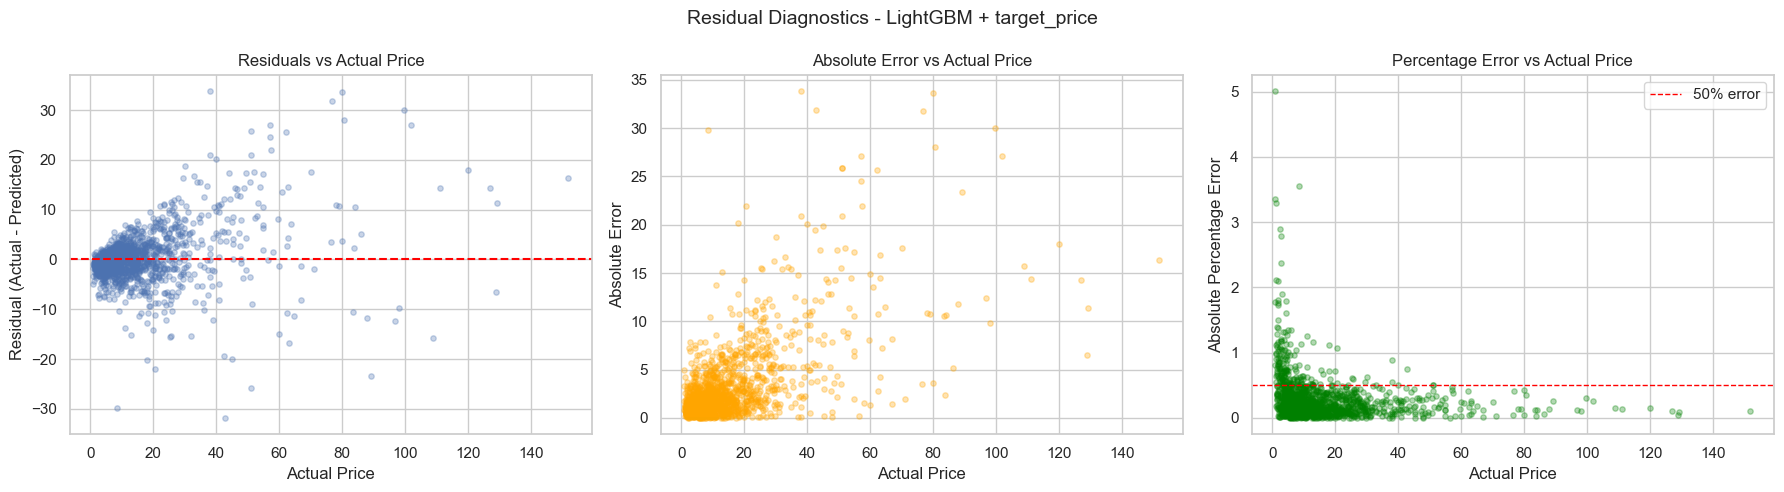

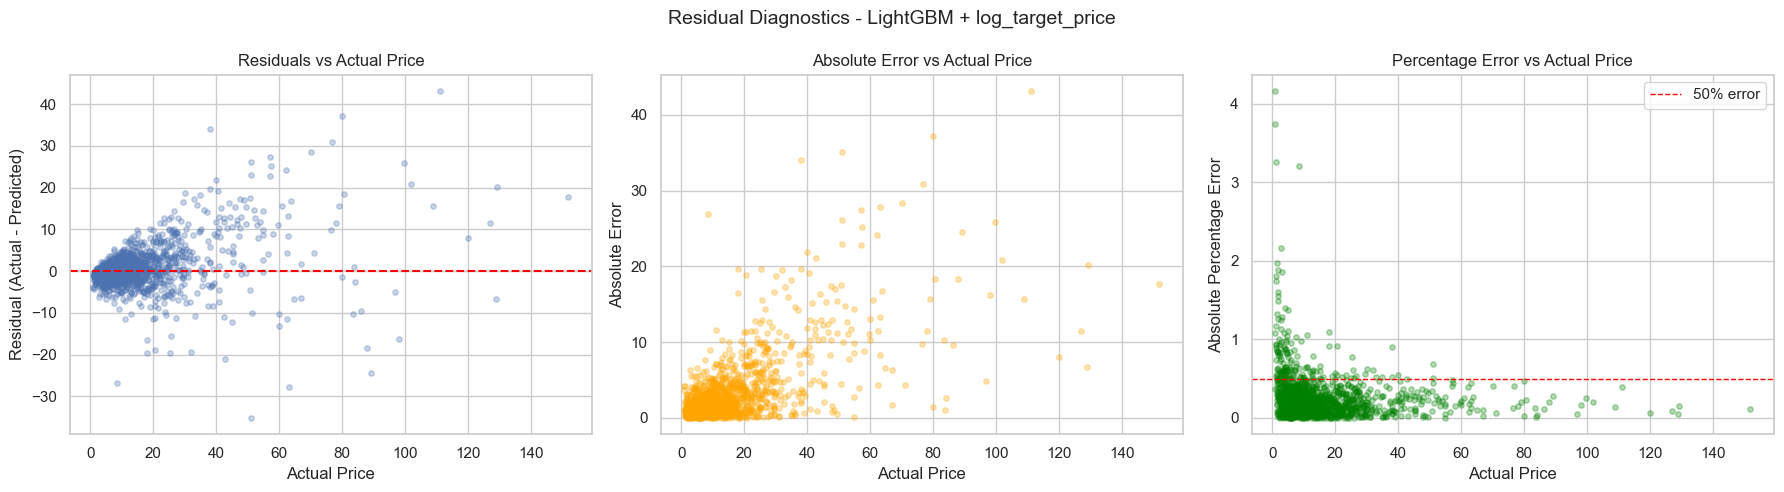

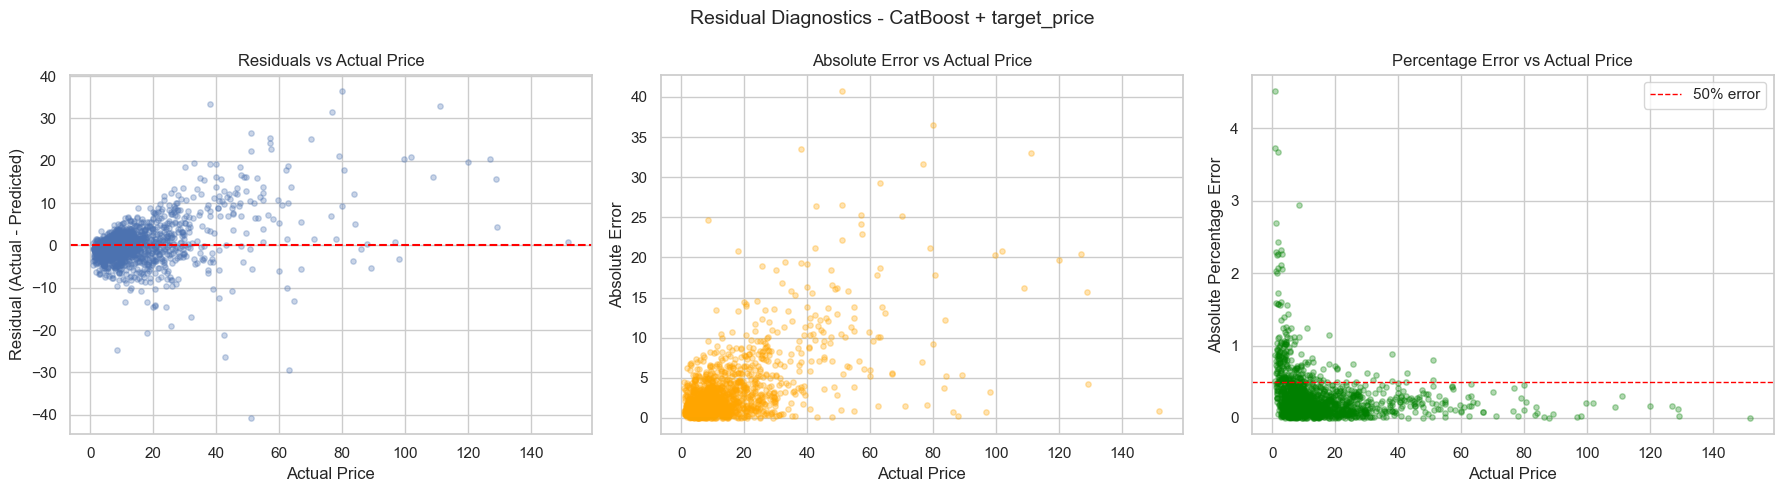

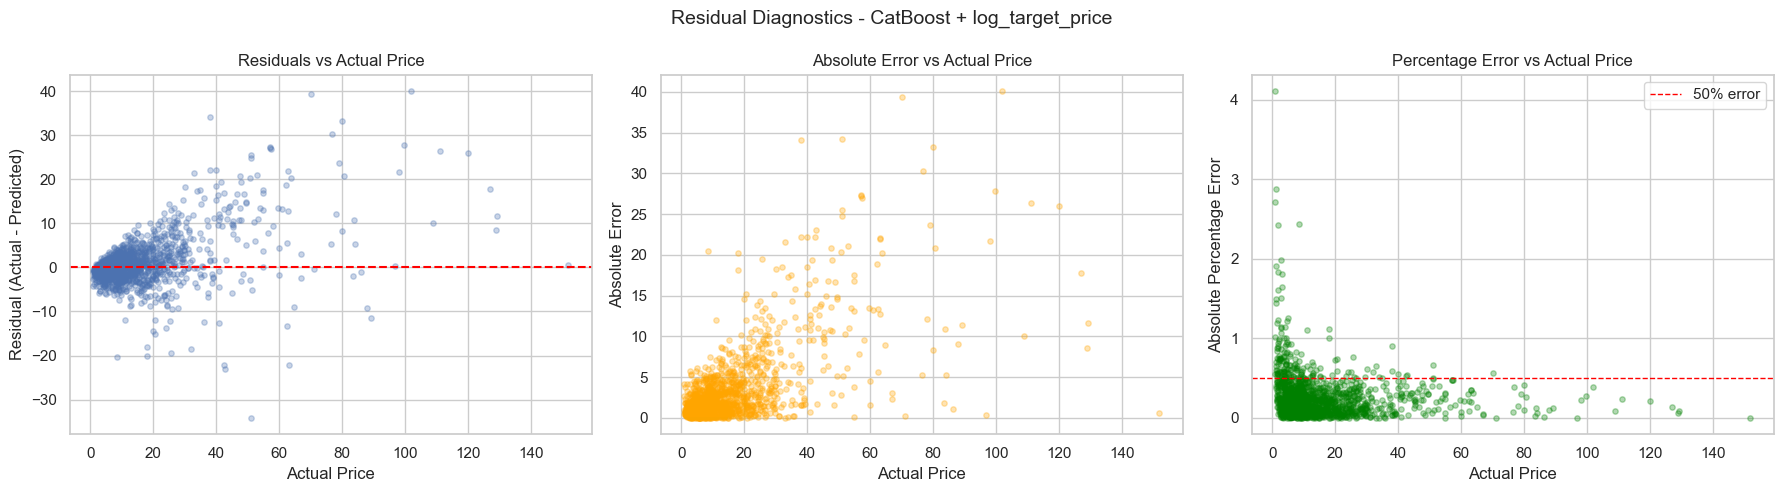

In [13]:
def plot_heteroscedasticity(diag_df, model_name, target_used, save_dir):
    """Three residual scatter plots for one model variant."""
    mask  = (diag_df['model_name'] == model_name) & (diag_df['target_used'] == target_used)
    grp   = diag_df[mask]
    label = f'{model_name} + {target_used}'
    fn    = safe_filename(model_name, target_used)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Residual Diagnostics - {label}', fontsize=14)

    axes[0].scatter(grp['actual_price'], grp['residual'], alpha=0.3, s=15)
    axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[0].set_xlabel('Actual Price')
    axes[0].set_ylabel('Residual (Actual - Predicted)')
    axes[0].set_title('Residuals vs Actual Price')

    axes[1].scatter(grp['actual_price'], grp['absolute_error'], alpha=0.3, s=15, color='orange')
    axes[1].set_xlabel('Actual Price')
    axes[1].set_ylabel('Absolute Error')
    axes[1].set_title('Absolute Error vs Actual Price')

    axes[2].scatter(grp['actual_price'], grp['absolute_percentage_error'], alpha=0.3, s=15, color='green')
    axes[2].axhline(0.5, color='red', linewidth=1, linestyle='--', label='50% error')
    axes[2].set_xlabel('Actual Price')
    axes[2].set_ylabel('Absolute Percentage Error')
    axes[2].set_title('Percentage Error vs Actual Price')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(save_dir / f'heteroscedasticity_{fn}.png', dpi=150, bbox_inches='tight')
    plt.show()


for model_name, target_used in available_model_targets:
    plot_heteroscedasticity(diag_df, model_name, target_used, DIAGNOSTICS_DIR)

### Nhận xét — Biểu đồ Residual Diagnostics (3 scatter plots)

Mỗi model-target combination tạo ra một hàng gồm ba scatter plots:

**Plot 1 — Residuals vs Actual Price**
- Trục X: actual price (triệu VND); Trục Y: residual = actual − predicted
- Đường đỏ nằm ngang tại 0 là đường lý tưởng (không sai số)
- **Nếu các điểm phân bố đều quanh đường 0**: không có global directional bias
- **Nếu hình phễu mở rộng về phía phải (giá cao)**: đây là dấu hiệu heteroscedasticity — model kém ổn định hơn ở vùng Premium
- **Nếu phần lớn điểm nằm trên 0 ở vùng giá thấp**: model đang underpredict các laptop rẻ (hoặc overpredict nếu dưới 0)

**Plot 2 — Absolute Error vs Actual Price**
- Trục Y: |residual| — chỉ thể hiện độ lớn của lỗi, không phân biệt hướng
- Các điểm tập trung ở vùng giá cao có absolute error lớn hơn xác nhận rằng sai số tuyệt đối tăng theo giá
- MAE và RMSE toàn cục bị chi phối bởi phần này nên không phản ánh đầy đủ chất lượng ở vùng giá thấp

**Plot 3 — Percentage Error vs Actual Price**
- Trục Y: APE = |residual| / actual — đo sai số tương đối
- Đường đỏ nằm ngang tại 0.5 đánh dấu ngưỡng "severe error" (sai > 50%)
- **Điểm quan trọng**: các extreme outlier (APE rất lớn) thường tập trung ở vùng giá **thấp**, không phải giá cao — vì khi actual price nhỏ, một absolute error nhỏ cũng tạo ra percentage error rất lớn
- Điều này giải thích tại sao MAPE cao ở Low segment không nhất thiết nghĩa là model sai nghiêm trọng theo nghĩa tuyệt đối

**Tóm tắt**: Nếu thấy ba plots đều có pattern fan-out (phân tán rộng hơn về phía phải), kết luận là **heteroscedasticity có mặt** và cần segment-aware tuning.


In [14]:
# Binned residual variance table
het_rows = []
for (model_name, target_used), grp in diag_df.groupby(["model_name", "target_used"], observed=True):
    grp = grp.copy()
    grp["price_bin"] = pd.qcut(grp["actual_price"], q=10, duplicates="drop")
    for bin_label, bin_grp in grp.groupby("price_bin", observed=True):
        metrics = compute_error_metrics(bin_grp["actual_price"], bin_grp["predicted_price"], bin_grp["residual"])
        het_rows.append({
            "model_name": model_name,
            "target_used": target_used,
            "price_bin": str(bin_label),
            "price_min": bin_grp["actual_price"].min(),
            "price_max": bin_grp["actual_price"].max(),
            "count": len(bin_grp),
            "residual_std": bin_grp["residual"].std(),
            "absolute_error_mean": bin_grp["absolute_error"].mean(),
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
        })
het_df = pd.DataFrame(het_rows)
het_df.to_csv(DIAGNOSTICS_DIR / "heteroscedasticity_binned_error_summary.csv", index=False)

for model_name in SELECTED_MODELS:
    if (model_name, PRIMARY_TARGET) not in available_model_targets:
        continue
    print(f"=== Binned Residual Variance - {model_name} + {PRIMARY_TARGET} ===")
    display(het_df[(het_df["model_name"] == model_name) & (het_df["target_used"] == PRIMARY_TARGET)][["price_bin", "price_min", "price_max", "count", "residual_std", "absolute_error_mean", "rmse", "mape"]])
    print()


=== Binned Residual Variance - LightGBM + target_price ===


,price_bin,price_min,price_max,count,residual_std,absolute_error_mean,rmse,mape
30,"(0.999, 3.5]",1.0000,3.5000,149,1.5483,1.3985,1.9345,0.6779
31,"(3.5, 5.0]",3.5500,5.0000,155,1.8565,1.6093,2.1607,0.3768
32,"(5.0, 6.5]",5.1000,6.5000,143,1.6996,1.2127,1.7466,0.2090
33,"(6.5, 8.1]",6.6000,8.1000,138,2.1416,1.6566,2.1512,0.2240
34,"(8.1, 10.15]",8.2000,10.0990,145,3.6238,2.2498,3.6377,0.2483
35,"(10.15, 12.99]",10.2000,12.9900,150,3.3315,2.4433,3.3206,0.2105
36,"(12.99, 16.5]",13.0000,16.5000,150,3.3346,2.5538,3.3240,0.1736
37,"(16.5, 21.999]",16.7000,21.9990,138,5.1888,3.7990,5.1974,0.1974
38,"(21.999, 31.49]",22.0000,31.4900,147,6.1024,5.1499,6.3686,0.1979
39,"(31.49, 151.89]",31.5000,151.8900,145,11.9890,10.2825,12.9460,0.1998



=== Binned Residual Variance - CatBoost + target_price ===


,price_bin,price_min,price_max,count,residual_std,absolute_error_mean,rmse,mape
10,"(0.999, 3.5]",1.0000,3.5000,149,1.6126,1.5253,2.0503,0.7425
11,"(3.5, 5.0]",3.5500,5.0000,155,1.8600,1.6225,2.2367,0.3824
12,"(5.0, 6.5]",5.1000,6.5000,143,1.8975,1.4310,1.9498,0.2455
13,"(6.5, 8.1]",6.6000,8.1000,138,2.4436,1.9384,2.4680,0.2629
14,"(8.1, 10.15]",8.2000,10.0990,145,3.5699,2.5290,3.6164,0.2791
15,"(10.15, 12.99]",10.2000,12.9900,150,3.4917,2.6306,3.4821,0.2265
16,"(12.99, 16.5]",13.0000,16.5000,150,3.2859,2.4853,3.2750,0.1684
17,"(16.5, 21.999]",16.7000,21.9990,138,5.0178,3.7935,5.0247,0.1978
18,"(21.999, 31.49]",22.0000,31.4900,147,5.7527,4.6979,6.0354,0.1804
19,"(31.49, 151.89]",31.5000,151.8900,145,11.5937,10.5799,13.3494,0.2092


### Nhận xét — Bảng Binned Residual Variance

Bảng này chia toàn bộ actual price thành 10 bins đều nhau theo quantile (mỗi bin khoảng 10% số lượng samples) và tính residual std, mean absolute error, RMSE trong từng bin.

**Cách đọc bảng**:
- Cột `price_min` và `price_max`: khoảng giá của bin đó
- Cột `residual_std`: độ lệch chuẩn của residuals — nếu tăng dần từ bin thấp đến bin cao → heteroscedasticity rõ ràng
- Cột `absolute_error_mean`: sai số tuyệt đối trung bình — tăng theo giá là kỳ vọng bình thường, nhưng mức độ tăng nói lên mức độ nghiêm trọng
- Cột `rmse`: RMSE trong từng bin — giúp so sánh bin nào đóng góp nhiều nhất vào global RMSE
- Cột `mape`: MAPE trong từng bin — thường cao nhất ở bin giá thấp nhất vì lý do denominator nhỏ

**Kết luận điển hình**: Nếu `residual_std` ở Premium bin gấp 3–5 lần ở Low bin, đây là bằng chứng định lượng rõ ràng của heteroscedasticity và cần xử lý trong bước tuning.

Kết quả được lưu vào `heteroscedasticity_binned_error_summary.csv` để tham chiếu lại khi thiết kế cross-validation trong notebook tiếp theo.


In [15]:
# Spearman correlation tests
hetero_evidence = []
for model_name in SELECTED_MODELS:
    main_grp = diag_df[(diag_df["model_name"] == model_name) & (diag_df["target_used"] == PRIMARY_TARGET)]
    if main_grp.empty:
        continue
    print(f"=== Correlation: Actual Price vs Error Magnitude ({model_name} + {PRIMARY_TARGET}) ===")
    r_main, p_main = np.nan, np.nan
    for err_col in ["absolute_error", "squared_error"]:
        r, p = stats.spearmanr(main_grp["actual_price"], main_grp[err_col])
        print(f"  actual_price vs {err_col}: rho={r:.3f}, p={p:.4f}")
        if err_col == "absolute_error":
            r_main, p_main = r, p
    flag = bool(r_main > 0.3 and p_main < 0.05)
    hetero_evidence.append({"model_name": model_name, "rho_abs_error": r_main, "p_value": p_main, "heteroscedasticity_flag": flag})
    if flag:
        print("  Positive correlation detected: heteroscedasticity is likely present.")
        print("  Next tuning should use segment-aware evaluation or sample weighting.")
    else:
        print("  No strong correlation between actual price and absolute error.")
    print()
hetero_evidence_df = pd.DataFrame(hetero_evidence)
hetero_evidence_df.to_csv(DIAGNOSTICS_DIR / "heteroscedasticity_correlation_tests.csv", index=False)


=== Correlation: Actual Price vs Error Magnitude (LightGBM + target_price) ===
  actual_price vs absolute_error: rho=0.499, p=0.0000
  actual_price vs squared_error: rho=0.499, p=0.0000
  Positive correlation detected: heteroscedasticity is likely present.
  Next tuning should use segment-aware evaluation or sample weighting.

=== Correlation: Actual Price vs Error Magnitude (CatBoost + target_price) ===
  actual_price vs absolute_error: rho=0.453, p=0.0000
  actual_price vs squared_error: rho=0.453, p=0.0000
  Positive correlation detected: heteroscedasticity is likely present.
  Next tuning should use segment-aware evaluation or sample weighting.



### Nhận xét — Spearman Correlation: Actual Price vs Error Magnitude

Test Spearman correlation đo tương quan thứ hạng (rank correlation) giữa actual price và absolute error — một cách kiểm định thống kê cho heteroscedasticity.

**Cách đọc kết quả**:
- `rho` (ρ): hệ số tương quan Spearman, từ -1 đến +1
  - ρ > 0.3 và p < 0.05: tương quan dương có ý nghĩa thống kê — model làm tệ hơn khi giá cao
  - ρ gần 0: không có mối quan hệ rõ ràng giữa giá và độ lớn lỗi
- `p-value`: xác suất quan sát được tương quan này nếu thực tế không có tương quan. p < 0.05 nghĩa là kết quả có ý nghĩa thống kê

**Hai biến được test**:
1. `actual_price vs absolute_error`: test chính
2. `actual_price vs squared_error`: squared error nhạy cảm hơn với outliers, cho thêm góc nhìn về ảnh hưởng của premium errors đến RMSE

**Kết luận thực hành**: Nếu flag `heteroscedasticity_flag = True`, bước tuning tiếp theo nên sử dụng segment-aware validation (đánh giá riêng từng segment) hoặc thử sample weighting để giảm tác động bất cân xứng của premium errors lên loss function.


## 7. Price Segment Bias Analysis

Phân tích bias theo từng price segment (Low / Mid / High / Premium) để phát hiện các vấn đề không nhìn thấy được từ global metrics.

**Giải thích các chỉ số bias**:

| Chỉ số | Ý nghĩa |
|---|---|
| `mean_residual > 0` | Model đang **underpredict** segment đó (actual − predicted > 0) |
| `mean_residual < 0` | Model đang **overpredict** segment đó (actual − predicted < 0) |
| `prediction_ratio > 1.0` | Predicted price **cao hơn** actual price → overprediction |
| `prediction_ratio < 1.0` | Predicted price **thấp hơn** actual price → underprediction |
| `underprediction_rate > 0.5` | Hơn 50% samples trong segment đó bị underpredict |

**Tại sao segment bias quan trọng?** Global MAE có thể trông ổn nhưng ẩn đi việc model đang sai theo hướng ngược nhau ở hai đầu price distribution. Ví dụ: MAE tổng thể = 3 triệu có thể được tạo ra bởi +8 triệu ở Premium và -5 triệu ở Low, triệt tiêu nhau theo hướng nhưng đều gây ra trải nghiệm người dùng kém.


In [16]:
seg_rows = []
for (model_name, target_used, segment), grp in diag_df.groupby(["model_name", "target_used", "price_segment"], observed=True):
    metrics = compute_error_metrics(grp["actual_price"], grp["predicted_price"], grp["residual"], grp["absolute_percentage_error"])
    seg_rows.append({
        "model_name": model_name,
        "target_used": target_used,
        "price_segment": segment,
        "count": len(grp),
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
        "median_absolute_error": metrics["median_absolute_error"],
        "mean_residual": metrics["mean_residual"],
        "median_residual": metrics["median_residual"],
        "underprediction_rate": metrics["underprediction_rate"],
        "overprediction_rate": metrics["overprediction_rate"],
        "prediction_ratio_mean": grp["prediction_ratio"].mean(),
        "prediction_ratio_median": grp["prediction_ratio"].median(),
    })
seg_df = pd.DataFrame(seg_rows)
seg_df.to_csv(DIAGNOSTICS_DIR / "price_segment_bias_summary.csv", index=False)
for model_name in SELECTED_MODELS:
    model_seg = seg_df[seg_df["model_name"] == model_name]
    if model_seg.empty:
        continue
    print(f"=== Segment Bias Summary - {model_name} ===")
    display(model_seg[["model_name", "target_used", "price_segment", "count", "mae", "rmse", "mape", "mean_residual", "underprediction_rate", "overprediction_rate", "prediction_ratio_mean"]])
    print()


=== Segment Bias Summary - LightGBM ===


,model_name,target_used,price_segment,count,mae,rmse,mape,mean_residual,underprediction_rate,overprediction_rate,prediction_ratio_mean
8,LightGBM,log_target_price,Low,366,1.2271,1.6795,0.3929,-0.7114,0.3142,0.6858,1.2709
9,LightGBM,log_target_price,Mid,364,1.7189,2.5669,0.2178,-0.0136,0.5495,0.4505,1.0030
10,LightGBM,log_target_price,High,365,2.6318,3.5086,0.1907,0.3717,0.5836,0.4164,0.9712
11,LightGBM,log_target_price,Premium,365,7.2946,9.9796,0.2047,3.3899,0.6630,0.3370,0.9164
12,LightGBM,target_price,Low,366,1.4731,2.0203,0.4762,-1.0535,0.2705,0.7295,1.3658
13,LightGBM,target_price,Mid,364,1.7772,2.7641,0.2250,-0.3386,0.4918,0.5082,1.0450
14,LightGBM,target_price,High,365,2.6787,3.6599,0.1928,-0.1323,0.5315,0.4685,1.0060
15,LightGBM,target_price,Premium,365,6.9701,9.4236,0.1987,2.7105,0.6192,0.3808,0.9360



=== Segment Bias Summary - CatBoost ===


,model_name,target_used,price_segment,count,mae,rmse,mape,mean_residual,underprediction_rate,overprediction_rate,prediction_ratio_mean
0,CatBoost,log_target_price,Low,366,1.2282,1.6663,0.3925,-0.7654,0.2951,0.7049,1.2837
1,CatBoost,log_target_price,Mid,364,1.7727,2.4602,0.2236,-0.0295,0.5632,0.4368,1.0039
2,CatBoost,log_target_price,High,365,2.6289,3.5285,0.1897,0.4029,0.5863,0.4137,0.9686
3,CatBoost,log_target_price,Premium,365,7.5964,10.4856,0.2113,4.5536,0.7123,0.2877,0.8906
4,CatBoost,target_price,Low,366,1.5503,2.1213,0.5085,-1.1540,0.2486,0.7514,1.4036
5,CatBoost,target_price,Mid,364,2.0609,2.8878,0.2628,-0.4927,0.4918,0.5082,1.0640
6,CatBoost,target_price,High,365,2.7375,3.6683,0.1979,-0.2194,0.5151,0.4849,1.0133
7,CatBoost,target_price,Premium,365,6.8942,9.5365,0.1949,3.3936,0.6493,0.3507,0.9241


### Nhận xét — Bảng Segment Bias Summary

Bảng này hiển thị MAE, RMSE, MAPE, mean residual, underprediction/overprediction rate, và prediction ratio trung bình cho từng tổ hợp (model × target × price_segment).

**Các pattern thường thấy**:

- **Low segment**: thường có `mean_residual` âm (overprediction) và `prediction_ratio > 1`. Nguyên nhân: tree models có xu hướng kéo predictions về phía mean (mean reversion), nên các laptop rất rẻ bị predict cao hơn thực tế
- **Premium segment**: thường có `mean_residual` dương (underprediction) và `prediction_ratio < 1`. Nguyên nhân: premium laptops thường có ít training samples hơn và các feature configurations hiếm gặp, khiến model không học được đủ để predict đúng
- **Mid và High segment**: thường là balanced nhất vì phần lớn training data nằm trong khoảng giá này

**Khi so sánh giữa `target_price` và `log_target_price`**: log-transform có thể làm giảm MAE tổng thể một chút, nhưng thường làm tăng thêm compression ở Premium (prediction_ratio thấp hơn 1 nhiều hơn), vì log-scale coi khoảng cách giữa 50 và 60 triệu bằng khoảng cách giữa 5 và 6 triệu.


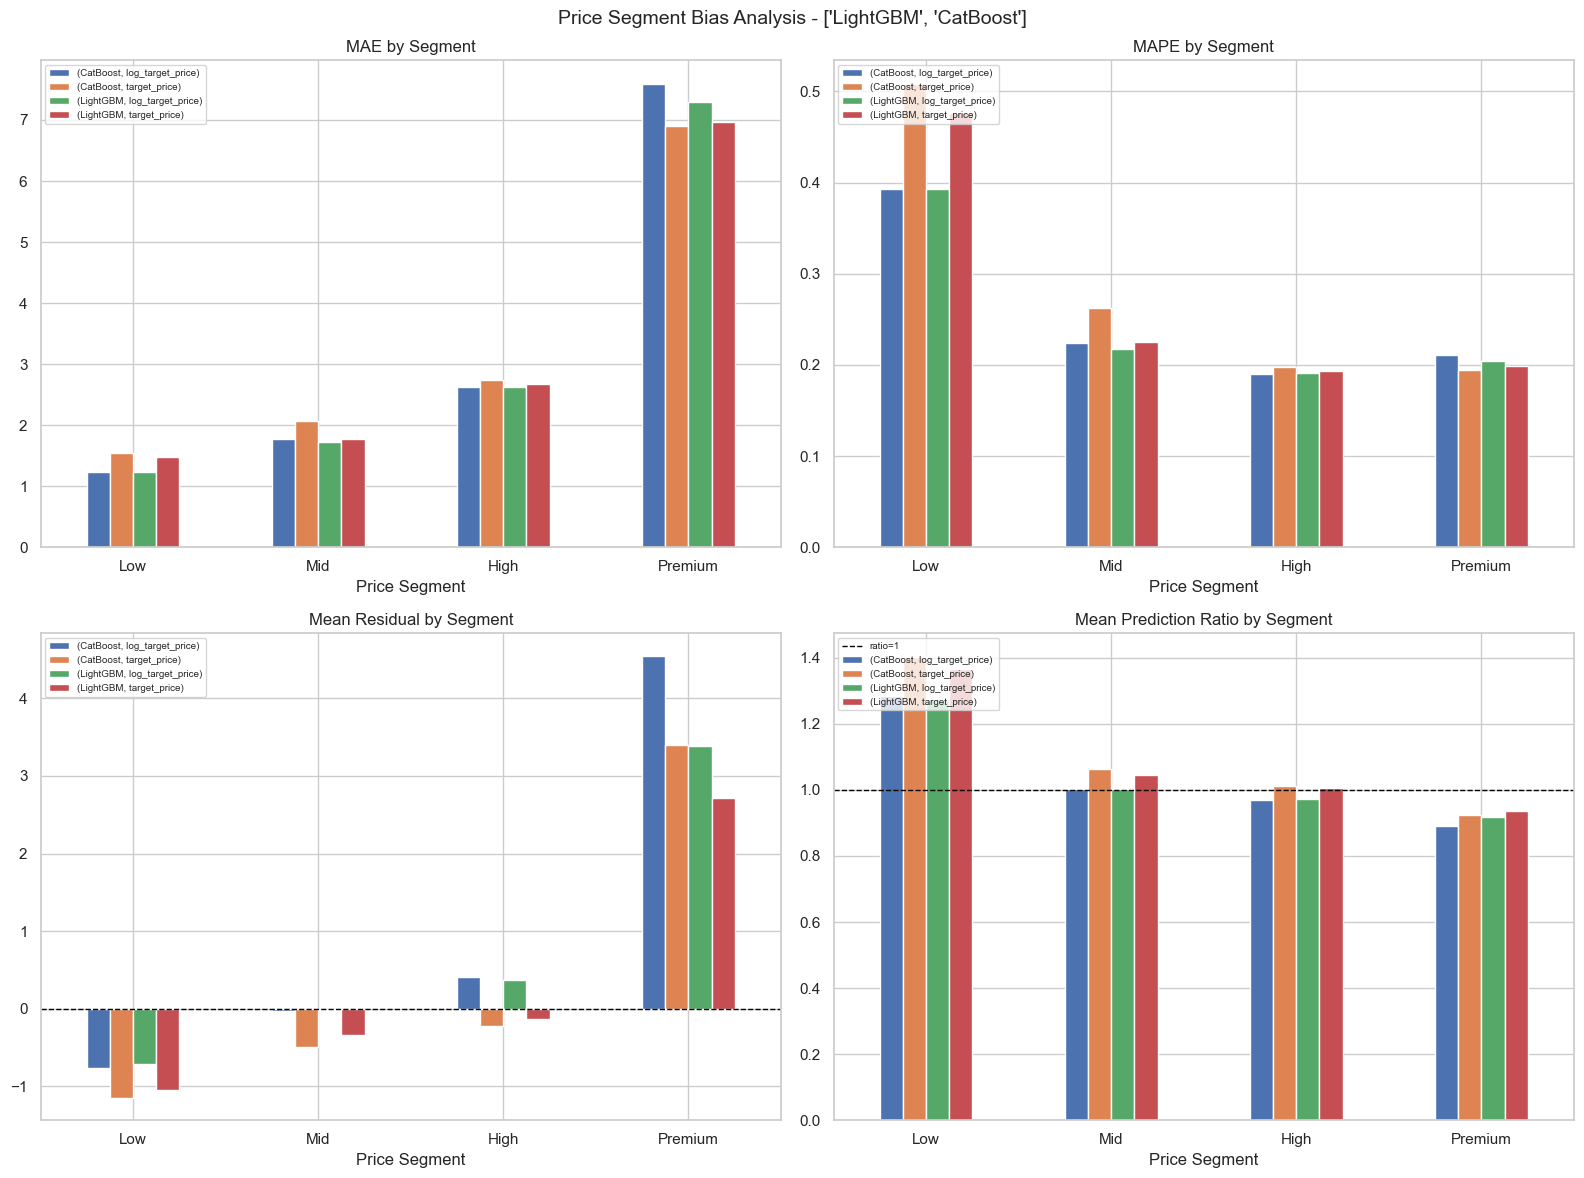

In [17]:
# ── Segment bias plots ─────────────────────────────────────────────────────────
segments_order = ['Low', 'Mid', 'High', 'Premium']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Price Segment Bias Analysis - {SELECTED_MODELS}', fontsize=14)

for ax, metric, title in zip(
    axes.flatten(),
    ['mae', 'mape', 'mean_residual', 'prediction_ratio_mean'],
    ['MAE by Segment', 'MAPE by Segment', 'Mean Residual by Segment', 'Mean Prediction Ratio by Segment'],
):
    pivot = seg_df.pivot_table(index='price_segment', columns=['model_name', 'target_used'], values=metric)
    pivot = pivot.reindex(segments_order)
    pivot.plot(kind='bar', ax=ax, legend=True)
    if metric == 'mean_residual':
        ax.axhline(0, color='black', linewidth=1, linestyle='--')
    if metric == 'prediction_ratio_mean':
        ax.axhline(1.0, color='black', linewidth=1, linestyle='--', label='ratio=1')
    ax.set_title(title)
    ax.set_xlabel('Price Segment')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / 'price_segment_bias_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### Nhận xét — Biểu đồ Price Segment Bias (4 subplots)

Bốn biểu đồ bar chart so sánh các metrics theo segment và model-target combination:

**Subplot 1 — MAE by Segment**
- Kỳ vọng: MAE tăng dần từ Low → Premium do price scale lớn hơn
- Nếu Premium MAE gấp 3–5 lần Low MAE: đây là dấu hiệu model kém ổn định ở vùng giá cao, cần đặc biệt chú ý khi tuning
- So sánh giữa `target_price` và `log_target_price`: log model có Premium MAE thấp hơn không? Hay giảm MAE ở chỗ này nhưng tăng ở chỗ khác?

**Subplot 2 — MAPE by Segment**
- Kỳ vọng *ngược*: MAPE cao nhất ở Low, thấp nhất ở Premium — vì actual price nhỏ làm phóng đại percentage error
- Nếu Low MAPE cực kỳ cao (> 100%) nhưng Low MAE chỉ ở mức bình thường: đây là artifact của denominator nhỏ, không nhất thiết là model sai nghiêm trọng theo nghĩa tuyệt đối
- **Không dùng MAPE như tiêu chí duy nhất để đánh giá Low segment**

**Subplot 3 — Mean Residual by Segment**
- Đường đứt đen tại 0 là điểm lý tưởng
- Các cột nằm trên 0 (dương): segment đó đang bị underpredict
- Các cột nằm dưới 0 (âm): segment đó đang bị overpredict
- Pattern điển hình: Low âm (overpredict) và Premium dương (underpredict) — xác nhận mean reversion và upper tail compression

**Subplot 4 — Mean Prediction Ratio by Segment**
- Đường đứt đen tại 1.0 là điểm lý tưởng (predicted = actual)
- Cột > 1.0: model đang predict cao hơn thực tế (overpredict)
- Cột < 1.0: model đang predict thấp hơn thực tế (underpredict)
- Đây là cách diễn giải trực quan nhất của bias: prediction_ratio = 1.3 nghĩa là model trung bình predict cao hơn thực tế 30%


In [18]:
# Segment bias interpretation
for model_name in SELECTED_MODELS:
    for target_used in ANALYZED_TARGETS:
        mask = (seg_df["model_name"] == model_name) & (seg_df["target_used"] == target_used)
        s = seg_df[mask].set_index("price_segment")
        if s.empty:
            continue
        print(f"=== {model_name} + {target_used} - Segment Interpretation ===")
        for seg in ["Low", "Premium"]:
            if seg not in s.index:
                continue
            row = s.loc[seg]
            direction = "underpredicts" if row["mean_residual"] > 0 else "overpredicts"
            print(f"  {seg}: mean_residual={row['mean_residual']:,.0f} ({direction}); over_rate={row['overprediction_rate']:.1%}; under_rate={row['underprediction_rate']:.1%}")
        print()


=== LightGBM + target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=73.0%; under_rate=27.0%
  Premium: mean_residual=3 (underpredicts); over_rate=38.1%; under_rate=61.9%

=== LightGBM + log_target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=68.6%; under_rate=31.4%
  Premium: mean_residual=3 (underpredicts); over_rate=33.7%; under_rate=66.3%

=== CatBoost + target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=75.1%; under_rate=24.9%
  Premium: mean_residual=3 (underpredicts); over_rate=35.1%; under_rate=64.9%

=== CatBoost + log_target_price - Segment Interpretation ===
  Low: mean_residual=-1 (overpredicts); over_rate=70.5%; under_rate=29.5%
  Premium: mean_residual=5 (underpredicts); over_rate=28.8%; under_rate=71.2%



### Nhận xét — Directional Bias của Low và Premium Segment

Section này in ra tóm tắt ngắn gọn về hướng bias ở hai segment quan trọng nhất: Low và Premium.

**Low segment**:
- `mean_residual` âm → model đang overpredict (predict cao hơn actual)
- `overprediction_rate` cao (> 60%) → không phải vài outliers mà là pattern hệ thống
- Nguyên nhân cốt lõi: tree models học từ phân phối training data, kéo predictions về phía các mức giá phổ biến (5–20 triệu) thay vì giữ ở mức rất thấp (< 3 triệu)

**Premium segment**:
- `mean_residual` dương → model đang underpredict (predict thấp hơn actual)
- `underprediction_rate` cao → pattern nhất quán, không chỉ một vài outliers
- Nguyên nhân cốt lõi: premium laptops (> Q75) thường ít hơn trong training data và có feature combinations độc đáo (high-end GPU, brand premium, rare configs), khiến model không học đủ để đẩy predictions lên cao

**Ý nghĩa thực hành**: pattern này — overpredict Low, underpredict Premium — là dạng **regression toward the mean** điển hình trong tree-based models. Khi tuning, cần xem xét:
- Sample weighting để tăng ảnh hưởng của premium samples
- Feature engineering cho các high-value configurations
- Segment-specific calibration sau khi có base model tốt


## 8. Premium Segment Deep Dive

Phân tích chi tiết các laptops thuộc **Premium segment** (actual price > Q75) — nhóm có MAE và RMSE lớn nhất nhưng thường ít samples nhất.

**Tại sao cần deep dive riêng?**
- Premium errors có absolute value lớn nhất → chi phối RMSE toàn cục
- Đây thường là nhóm khách hàng quan trọng nhất về giá trị kinh doanh
- Underprediction ở Premium có thể gây mất tin tưởng nếu người dùng thấy model luôn predict thấp hơn giá thật

Diagnostic chính dùng `LightGBM + target_price`; các model-target pair còn lại chỉ đóng vai trò so sánh.


In [19]:
premium_mask = diag_df['price_segment'] == 'Premium'
premium_df   = diag_df[premium_mask].copy()

print('=== Premium Segment - Summary (SELECTED_MODELS) ===')
prem_rows = []
for (model_name, target_used), grp in premium_df.groupby(['model_name', 'target_used'], observed=True):
    yt  = grp['actual_price'].values
    yp  = grp['predicted_price'].values
    res = grp['residual'].values
    prem_rows.append({
        'model_name':            model_name,
        'target_used':           target_used,
        'count':                 len(yt),
        'mae':                   mean_absolute_error(yt, yp),
        'rmse':                  root_mean_squared_error(yt, yp),
        'mape':                  mean_absolute_percentage_error(yt, yp),
        'mean_residual':         res.mean(),
        'underprediction_rate':  (res > 0).mean(),
        'prediction_ratio_mean': grp['prediction_ratio'].mean(),
        'prediction_ratio_median': grp['prediction_ratio'].median(),
    })

prem_summary = pd.DataFrame(prem_rows)
prem_summary.to_csv(DIAGNOSTICS_DIR / 'premium_segment_diagnostics.csv', index=False)
display(prem_summary)

=== Premium Segment - Summary (SELECTED_MODELS) ===


,model_name,target_used,count,mae,rmse,mape,mean_residual,underprediction_rate,prediction_ratio_mean,prediction_ratio_median
0,CatBoost,log_target_price,365,7.5964,10.4856,0.2113,4.5536,0.7123,0.8906,0.8860
1,CatBoost,target_price,365,6.8942,9.5365,0.1949,3.3936,0.6493,0.9241,0.9124
2,LightGBM,log_target_price,365,7.2946,9.9796,0.2047,3.3899,0.6630,0.9164,0.8963
3,LightGBM,target_price,365,6.9701,9.4236,0.1987,2.7105,0.6192,0.9360,0.9122


### Nhận xét — Bảng Premium Segment Summary

Bảng tóm tắt các metrics cho riêng Premium segment: count, MAE, RMSE, MAPE, mean residual, underprediction rate, và prediction ratio.

**Các chỉ số cần chú ý**:
- `mean_residual` > 0: xác nhận underprediction. Giá trị càng lớn → model càng thiếu sót ở upper tail
- `underprediction_rate` > 0.5: hơn nửa số premium laptops bị predict thấp hơn thực tế — không phải ngẫu nhiên
- `prediction_ratio_mean` < 1.0: trung bình model predict thấp hơn actual. Ví dụ: ratio = 0.85 nghĩa là model chỉ capture được 85% của actual price ở Premium segment

**So sánh giữa model-target pairs**:
- Nếu `LightGBM + log_target_price` có prediction_ratio thấp hơn `LightGBM + target_price` ở Premium: log-transform đang nén predictions ở vùng giá cao — đây là cost của log-scale training
- Nếu CatBoost có underprediction_rate thấp hơn LightGBM: CatBoost có thể xử lý premium segment tốt hơn, cần kiểm tra lại sau tuning

Kết quả được lưu vào `premium_segment_diagnostics.csv`.


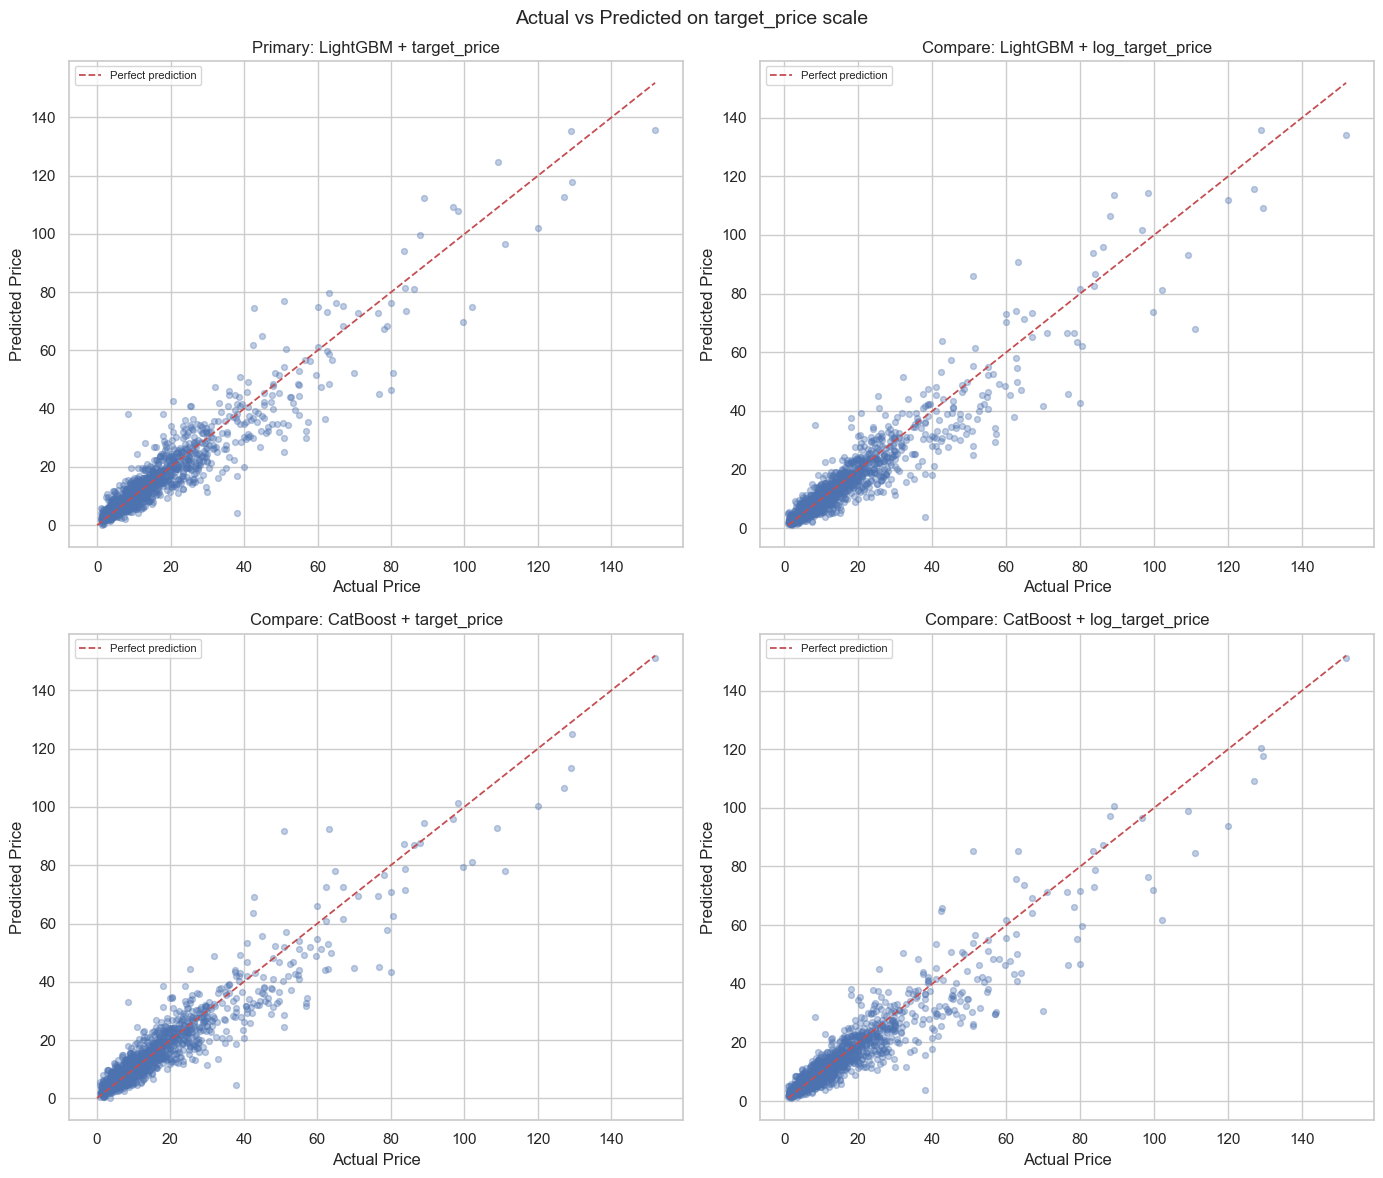

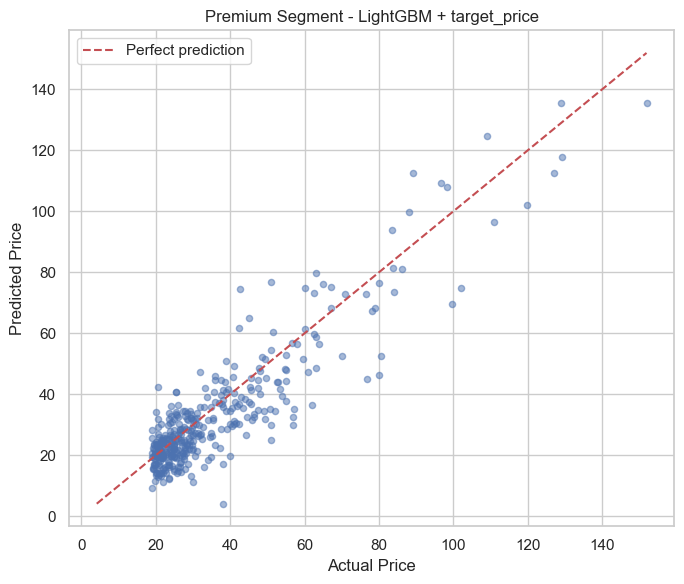

In [20]:
# Actual vs Predicted: primary candidate first, secondary candidates as comparison
plot_pairs = [(PRIMARY_MODEL, PRIMARY_TARGET)] + [
    pair for pair in available_model_targets if pair != (PRIMARY_MODEL, PRIMARY_TARGET)
]

n_pairs = len(plot_pairs)
n_cols = 2
n_rows = int(np.ceil(n_pairs / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)
fig.suptitle("Actual vs Predicted on target_price scale", fontsize=14)

for ax, (model_name, target_used) in zip(axes, plot_pairs):
    grp = diag_df[(diag_df["model_name"] == model_name) & (diag_df["target_used"] == target_used)]
    ax.scatter(grp["actual_price"], grp["predicted_price"], alpha=0.35, s=18)
    lim_min = min(grp["actual_price"].min(), grp["predicted_price"].min())
    lim_max = max(grp["actual_price"].max(), grp["predicted_price"].max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.3, label="Perfect prediction")
    title_prefix = "Primary: " if (model_name, target_used) == (PRIMARY_MODEL, PRIMARY_TARGET) else "Compare: "
    ax.set_title(f"{title_prefix}{model_name} + {target_used}")
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.legend(fontsize=8)

for ax in axes[n_pairs:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / f"{output_prefix}_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

# Premium-only view for the primary diagnostic pair.
main_premium_plot = premium_df[(premium_df["model_name"] == PRIMARY_MODEL) & (premium_df["target_used"] == PRIMARY_TARGET)]
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(main_premium_plot["actual_price"], main_premium_plot["predicted_price"], alpha=0.5, s=20)
lim_min = min(main_premium_plot["actual_price"].min(), main_premium_plot["predicted_price"].min())
lim_max = max(main_premium_plot["actual_price"].max(), main_premium_plot["predicted_price"].max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=1.5, label="Perfect prediction")
ax.set_title(f"Premium Segment - {PRIMARY_MODEL} + {PRIMARY_TARGET}")
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.legend()
plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / f"{output_prefix}_premium_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

### Nhận xét — Biểu đồ Actual vs Predicted

**Biểu đồ chính** (`Primary: LightGBM + target_price`) và **biểu đồ phụ** (các cấu hình còn lại) đều vẽ actual price (trục X) vs predicted price (trục Y). **Đường đỏ đứt** là đường lý tưởng y = x (perfect prediction).

**Cách đọc biểu đồ**:
- Điểm **trên** đường đỏ: predicted > actual → model đang overpredict (điển hình ở vùng giá thấp)
- Điểm **dưới** đường đỏ: predicted < actual → model đang underpredict (điển hình ở vùng giá cao)
- **Scatter rộng** quanh đường đỏ: model thiếu precision
- Điểm tập trung sát đường đỏ ở giữa nhưng phân tán ở hai đầu: model học tốt cho mid-range nhưng kém ở extremes

**Premium-only view** (biểu đồ riêng cho Premium segment):
- Tập trung vào upper tail để thấy rõ hơn mức độ underprediction
- Nếu phần lớn điểm nằm dưới đường đỏ (cluster of points below y=x line): xác nhận systemic underprediction
- Điểm nào cách xa đường đỏ nhất ở vùng Premium là ứng viên cho premium error case review ở bước tiếp theo

**So sánh giữa các biểu đồ phụ**:
- Nếu log-target plots có điểm clustered chặt hơn ở Premium: log-transform đang giúp về relative error
- Nếu log-target plots có điểm dưới đường đỏ nhiều hơn ở Premium: log-transform tạo compression rõ hơn, cần cân nhắc kỹ


In [21]:
# Premium: top error cases for primary pair
main_premium = premium_df[(premium_df["model_name"] == PRIMARY_MODEL) & (premium_df["target_used"] == PRIMARY_TARGET)].copy()
top20_premium = main_premium.nlargest(20, "absolute_error")
top20_premium.to_csv(DIAGNOSTICS_DIR / "premium_top_error_cases.csv", index=False)
print(f"=== Top 20 Premium Error Cases ({PRIMARY_MODEL} + {PRIMARY_TARGET}) ===")
display(top20_premium[["sample_id", "actual_price", "predicted_price", "residual", "absolute_error", "absolute_percentage_error"]].head(20))


=== Top 20 Premium Error Cases (LightGBM + target_price) ===


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error
909,5008,38.0000,4.1540,33.8460,33.8460,0.8907
1120,6456,79.9900,46.3654,33.6246,33.6246,0.4204
523,5983,42.7000,74.5314,-31.8314,31.8314,0.7455
1319,6753,76.7900,44.9923,31.7977,31.7977,0.4141
72,5735,99.6900,69.7063,29.9837,29.9837,0.3008
438,5683,80.4900,52.4239,28.0661,28.0661,0.3487
844,6799,56.9900,29.9203,27.0697,27.0697,0.4750
1149,6067,102.0000,74.9333,27.0667,27.0667,0.2654
870,3296,51.0000,25.1019,25.8981,25.8981,0.5078
420,7187,50.9990,76.8330,-25.8340,25.8340,0.5066


### Nhận xét — Top 20 Premium Error Cases

Bảng này liệt kê 20 premium laptops có absolute error lớn nhất từ cấu hình chính `LightGBM + target_price`.

**Cách đọc bảng**:
- `actual_price`: giá thật của laptop (triệu VND) — thường rất cao do đây là Premium segment
- `predicted_price`: giá mà model đoán — thường thấp hơn actual
- `residual` = actual − predicted: dương nghĩa là underpredict. Ví dụ: residual = 25 nghĩa là model đoán thấp hơn thực tế 25 triệu VND
- `absolute_error`: giá trị tuyệt đối của sai số — đây là cột dùng để sort
- `absolute_percentage_error`: sai số tương đối — ở Premium segment thường thấp hơn Low segment dù absolute error lớn hơn nhiều

**Những gì nên làm với kết quả này**:
1. Tra cứu các `sample_id` này trong original data để xem chúng có feature gì đặc biệt (GPU model, RAM, brand, condition)
2. Kiểm tra xem chúng có phải là valid listings hay là data quality issues (giá nhập sai, thông số hardware hiếm gặp)
3. Nếu là valid hard cases: cân nhắc feature engineering thêm cho rare high-value configs
4. Nếu là data issues: xem xét removal trước tuning

File `premium_top_error_cases.csv` lưu 20 cases này để tiện tra cứu.


## 9. Low-Price Segment Deep Dive

Phân tích chi tiết các laptops thuộc **Low segment** (actual price ≤ Q25) — nhóm thường bị overpredict do hiệu ứng mean reversion trong tree models.

**Tại sao cần deep dive riêng?**
- Low segment có MAPE cao nhất nhưng absolute error thấp nhất — mâu thuẫn này cần được giải thích rõ
- Overprediction ở Low segment có thể có nhiều nguyên nhân: thiếu training samples ở vùng giá rất thấp, data quality issues (giá nhập sai), hoặc các sản phẩm cũ/damaged không được model học đủ
- Việc phân biệt "valid hard cases" với "data noise" ở đây quan trọng trước khi tuning


In [22]:
low_mask = diag_df["price_segment"] == "Low"
low_df = diag_df[low_mask].copy()

print("=== Low-Price Segment Summary ===")
low_rows = []
for (model_name, target_used), grp in low_df.groupby(["model_name", "target_used"], observed=True):
    metrics = compute_error_metrics(grp["actual_price"], grp["predicted_price"], grp["residual"], grp["absolute_percentage_error"])
    low_rows.append({
        "model_name": model_name,
        "target_used": target_used,
        "count": len(grp),
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
        "mean_residual": metrics["mean_residual"],
        "overprediction_rate": metrics["overprediction_rate"],
        "prediction_ratio_mean": grp["prediction_ratio"].mean(),
    })
low_summary = pd.DataFrame(low_rows)
low_summary.to_csv(DIAGNOSTICS_DIR / "low_price_segment_diagnostics.csv", index=False)
display(low_summary)


=== Low-Price Segment Summary ===


,model_name,target_used,count,mae,rmse,mape,mean_residual,overprediction_rate,prediction_ratio_mean
0,CatBoost,log_target_price,366,1.2282,1.6663,0.3925,-0.7654,0.7049,1.2837
1,CatBoost,target_price,366,1.5503,2.1213,0.5085,-1.1540,0.7514,1.4036
2,LightGBM,log_target_price,366,1.2271,1.6795,0.3929,-0.7114,0.6858,1.2709
3,LightGBM,target_price,366,1.4731,2.0203,0.4762,-1.0535,0.7295,1.3658


### Nhận xét — Bảng Low-Price Segment Summary

Bảng tóm tắt MAE, RMSE, MAPE, mean residual, overprediction rate, và prediction ratio cho Low segment.

**Các chỉ số cần chú ý**:
- `mean_residual` âm: xác nhận overprediction. Ví dụ: mean_residual = -5 nghĩa là model trung bình predict cao hơn actual 5 triệu
- `overprediction_rate` > 0.6: phần lớn low-price listings đều bị predict cao hơn thực tế
- `prediction_ratio_mean` > 1.3: model trung bình predict cao hơn actual 30% ở Low segment
- **MAPE rất cao** (thường > 50–100%): điều này chủ yếu do actual price nhỏ, không hẳn là model sai tệ theo nghĩa tuyệt đối

**So sánh với log-target models**:
- `LightGBM + log_target_price` thường có Low-segment MAPE thấp hơn raw target vì log-scale cân bằng lại relative errors
- Nhưng trade-off là Premium compression tăng — cần đánh giá tổng thể thay vì chỉ nhìn Low-segment

Kết quả được lưu vào `low_price_segment_diagnostics.csv`.


In [23]:
# Low-price: top overpredicted cases for primary pair
main_low = low_df[(low_df["model_name"] == PRIMARY_MODEL) & (low_df["target_used"] == PRIMARY_TARGET)].copy()
top_low_over = main_low[main_low["residual"] < 0].nsmallest(20, "residual")
top_low_over.to_csv(DIAGNOSTICS_DIR / "low_price_top_error_cases.csv", index=False)
print("=== Top 20 Overpredicted Low-Price Cases ===")
display(top_low_over[["sample_id", "actual_price", "predicted_price", "residual", "absolute_percentage_error"]].head(20))

over_rate = (main_low["residual"] < 0).mean() if len(main_low) else np.nan
print(f"\nOverprediction rate for Low-price segment ({PRIMARY_MODEL} + {PRIMARY_TARGET}): {over_rate:.1%}")
if over_rate > 0.55:
    print("Model tends to overpredict low-price laptops, consistent with mean-reversion.")
else:
    print("No strong overprediction bias in the low-price segment for the primary pair.")


=== Top 20 Overpredicted Low-Price Cases ===


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error
1213,5045,2.8000,10.6244,-7.8244,2.7944
846,3878,4.2000,11.7416,-7.5416,1.7956
1450,527,4.5000,11.7416,-7.2416,1.6092
534,4394,2.5000,9.7239,-7.2239,2.8896
486,1144,2.9000,9.8004,-6.9004,2.3794
123,5857,4.8450,11.3667,-6.5217,1.3461
841,6060,5.6900,12.1606,-6.4706,1.1372
9,1662,4.7000,10.6794,-5.9794,1.2722
566,3982,3.0000,8.6887,-5.6887,1.8962
235,5242,5.5000,10.8284,-5.3284,0.9688



Overprediction rate for Low-price segment (LightGBM + target_price): 73.0%
Model tends to overpredict low-price laptops, consistent with mean-reversion.


### Nhận xét — Top 20 Overpredicted Low-Price Cases

Bảng này liệt kê 20 low-price laptops bị overpredict nhiều nhất (residual âm lớn nhất về độ tuyệt đối) từ cấu hình chính.

**Cách đọc bảng**:
- `residual` âm: predicted > actual (overpredict). Ví dụ: residual = -12 nghĩa là model đoán cao hơn thực tế 12 triệu
- `absolute_percentage_error` rất cao: do actual price cực nhỏ, ví dụ actual = 1.0 triệu mà model predict 14 triệu → APE = 1300%
- Các cases có actual price gần 0–2 triệu: đây là mức giá không bình thường và cần review đặc biệt

**Phân tích nguyên nhân**:
- **Mean reversion**: model học từ phân phối giá 5–20 triệu (phổ biến nhất), khi gặp laptop 1–2 triệu, model không có điểm tham chiếu tốt và kéo prediction về vùng phổ biến
- **Data quality**: laptops giá cực thấp có thể là lỗi nhập liệu, sản phẩm hỏng không có thông tin, hoặc khuyến mãi đặc biệt không phản ánh giá trị thực
- **Sparse training data**: ít samples ở vùng giá này → model underfits cho Low segment

**Quyết định cần làm trước tuning**: Tra cứu original features của các sample_id này để quyết định giữ lại, reweight, hay loại bỏ trước khi tuning.

Overprediction rate được in tự động cùng với threshold kiểm tra có > 55% hay không.


## 10. Top Error Case Analysis

Xem xét các samples có lỗi lớn nhất theo nhiều tiêu chí khác nhau để hiểu nguồn gốc sai số — từ price segment cụ thể hay từ data quality issues.

**Bốn tiêu chí được dùng để chọn top errors**:

| Danh sách | Tiêu chí | Mục đích |
|---|---|---|
| Top absolute error | `absolute_error` lớn nhất | Tìm cases gây thiệt hại lớn nhất tính bằng VND |
| Top percentage error | `absolute_percentage_error` lớn nhất | Tìm cases sai tỷ lệ cao nhất (thường ở Low segment) |
| Top underpredicted | `residual` dương lớn nhất | Tìm cases bị predict thấp hơn thực tế nhiều nhất |
| Top overpredicted | `residual` âm nhỏ nhất | Tìm cases bị predict cao hơn thực tế nhiều nhất |

Mỗi danh sách lấy top 30 cases và được lưu riêng ra file CSV. Segment distribution của top 30 absolute errors cũng được in ra để kiểm tra nhanh xem errors tập trung ở segment nào.


In [24]:
base_cols = ['sample_id', 'actual_price', 'predicted_price', 'residual',
             'absolute_error', 'absolute_percentage_error', 'price_segment']

primary_error_df = diag_df[
    (diag_df['model_name'] == PRIMARY_MODEL) & (diag_df['target_used'] == PRIMARY_TARGET)
].copy()

primary_top_abs   = primary_error_df.nlargest(30, 'absolute_error')
primary_top_pct   = primary_error_df.nlargest(30, 'absolute_percentage_error')
primary_top_under = primary_error_df.nlargest(30, 'residual')
primary_top_over  = primary_error_df.nsmallest(30, 'residual')

primary_top_abs[base_cols].to_csv(DIAGNOSTICS_DIR / f'{output_prefix}_top_absolute_error.csv', index=False)
primary_top_pct[base_cols].to_csv(DIAGNOSTICS_DIR / f'{output_prefix}_top_percentage_error.csv', index=False)
primary_top_under[base_cols].to_csv(DIAGNOSTICS_DIR / f'{output_prefix}_top_underpredicted.csv', index=False)
primary_top_over[base_cols].to_csv(DIAGNOSTICS_DIR / f'{output_prefix}_top_overpredicted.csv', index=False)

print(f'=== Primary: {PRIMARY_MODEL} + {PRIMARY_TARGET} - Top 10 by Absolute Error ===')
display(primary_top_abs[base_cols].head(10))
print(f'\n=== Primary: {PRIMARY_MODEL} + {PRIMARY_TARGET} - Segment distribution in Top 30 Absolute Errors ===')
print(primary_top_abs['price_segment'].value_counts())

# Secondary comparison exports for the same primary target.
for model_name in SELECTED_MODELS:
    main_all = diag_df[
        (diag_df['model_name'] == model_name) & (diag_df['target_used'] == PRIMARY_TARGET)
    ].copy()

    if main_all.empty:
        continue

    top_abs   = main_all.nlargest(30, 'absolute_error')
    top_pct   = main_all.nlargest(30, 'absolute_percentage_error')
    top_under = main_all.nlargest(30, 'residual')
    top_over  = main_all.nsmallest(30, 'residual')

    fn = safe_filename(model_name, PRIMARY_TARGET)
    top_abs[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_absolute_error_{fn}.csv', index=False)
    top_pct[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_percentage_error_{fn}.csv', index=False)
    top_under[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_underpredicted_{fn}.csv', index=False)
    top_over[base_cols].to_csv(DIAGNOSTICS_DIR / f'top_overpredicted_{fn}.csv', index=False)

print('\nSaved primary top-error files and secondary comparison top-error files.')

=== Primary: LightGBM + target_price - Top 10 by Absolute Error ===


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,price_segment
909,5008,38.0000,4.1540,33.8460,33.8460,0.8907,Premium
1120,6456,79.9900,46.3654,33.6246,33.6246,0.4204,Premium
523,5983,42.7000,74.5314,-31.8314,31.8314,0.7455,Premium
1319,6753,76.7900,44.9923,31.7977,31.7977,0.4141,Premium
72,5735,99.6900,69.7063,29.9837,29.9837,0.3008,Premium
1112,6072,8.3900,38.2120,-29.8220,29.8220,3.5545,Mid
438,5683,80.4900,52.4239,28.0661,28.0661,0.3487,Premium
844,6799,56.9900,29.9203,27.0697,27.0697,0.4750,Premium
1149,6067,102.0000,74.9333,27.0667,27.0667,0.2654,Premium
870,3296,51.0000,25.1019,25.8981,25.8981,0.5078,Premium



=== Primary: LightGBM + target_price - Segment distribution in Top 30 Absolute Errors ===
price_segment
Premium    28
Mid         1
High        1
Low         0
Name: count, dtype: int64

Saved primary top-error files and secondary comparison top-error files.


### Nhận xét — Bảng Top Error Cases

**Segment distribution trong Top 30 Absolute Errors**:
- Nếu Premium chiếm đa số (ví dụ: 20/30 cases là Premium): các absolute errors lớn nhất đến từ vùng giá cao, đây là vấn đề calibration ở upper tail
- Nếu Premium và High cùng chiếm nhiều: vấn đề rộng hơn ở mid-to-high range
- Nếu Low chiếm nhiều trong top absolute errors: đây là dấu hiệu bất thường, vì Low prices nhỏ thì absolute errors thường nhỏ → có thể là data quality issues ở Low segment

**Bảng Top 10 by Absolute Error**:
- Các rows đầu tiên thường là Premium laptops với actual price > Q75
- residual dương (underpredict) hoặc âm (overpredict)
- Xem thêm `price_segment` để biết errors tập trung ở segment nào

**Tại sao xuất cả 4 danh sách**:
- Absolute errors tập trung ở Premium (price scale lớn)
- Percentage errors tập trung ở Low (denominator nhỏ)
- Underpredicted cases = premium laptops mà model bỏ sót giá trị
- Overpredicted cases = low-price laptops bị kéo lên cao

Tất cả files được export để tiện tra cứu khi cần xem xét feature-level của specific cases.


## 11. Log-Target Compression Check

So sánh hành vi của `log_target_price` và `target_price` theo từng price segment để phát hiện xem **log-transform có làm nén predictions ở vùng giá cao không**.

**Background — tại sao log-transform có thể gây compression?**

Khi train model với `log(price)` thay vì `price`:
- Trong log-space: khoảng cách từ log(5) đến log(10) bằng khoảng cách từ log(50) đến log(100)
- Khi back-transform về original scale: model có xu hướng "gom" predictions về gần mean hơn
- Kết quả: Premium predictions sau exp() thường thấp hơn raw-target model → prediction_ratio < 1 ở Premium

**Chỉ số chính cần theo dõi**:
- `pred_ratio_log_mean` vs `pred_ratio_raw_mean` tại Premium: nếu log < raw → compression có mặt
- `underpred_log` vs `underpred_raw` tại Premium: nếu log > raw → log-target underpredict nhiều hơn ở Premium


In [25]:
for model_name in SELECTED_MODELS:
    log_col = f'pred_{safe_filename(model_name, "log_target_price")}'
    raw_col = f'pred_{safe_filename(model_name, "target_price")}'

    if log_col not in predictions_raw.columns or raw_col not in predictions_raw.columns:
        print(f'{model_name}: one or both target columns not found - skipping compression check.')
        continue

    actual   = predictions_raw[actual_col].values
    pred_log = predictions_raw[log_col].values
    pred_raw = predictions_raw[raw_col].values

    comp_df = pd.DataFrame({
        'actual_price':        actual,
        'pred_log':            pred_log,
        'pred_raw':            pred_raw,
        'residual_log':        actual - pred_log,
        'residual_raw':        actual - pred_raw,
        'prediction_ratio_log': pred_log / (actual + 1e-9),
        'prediction_ratio_raw': pred_raw / (actual + 1e-9),
    })
    comp_df['price_segment'] = comp_df['actual_price'].apply(assign_segment)
    comp_df['price_segment'] = pd.Categorical(
        comp_df['price_segment'], categories=['Low', 'Mid', 'High', 'Premium'], ordered=True
    )

    seg_comp = comp_df.groupby('price_segment', observed=True).agg(
        count=('actual_price', 'count'),
        pred_ratio_log_mean=('prediction_ratio_log', 'mean'),
        pred_ratio_raw_mean=('prediction_ratio_raw', 'mean'),
        residual_log_mean=('residual_log', 'mean'),
        residual_raw_mean=('residual_raw', 'mean'),
        underpred_log=('residual_log', lambda x: (x > 0).mean()),
        underpred_raw=('residual_raw', lambda x: (x > 0).mean()),
    ).reset_index()

    seg_comp.to_csv(DIAGNOSTICS_DIR / f'{MODEL_NAME_FOR_FILE.get(model_name, model_name)}_log_vs_raw_compression.csv', index=False)
    print(f'=== {model_name} - Log vs Raw Compression Check by Segment ===')
    display(seg_comp)

    # Interpretation
    if 'Premium' in seg_comp['price_segment'].values:
        prem = seg_comp[seg_comp['price_segment'] == 'Premium'].iloc[0]
        if prem['pred_ratio_log_mean'] < prem['pred_ratio_raw_mean']:
            print(f'Log-target has lower prediction ratio than raw-target in Premium segment.')
            print(f'    -> Log-transform compresses high-price predictions - underprediction bias.')
        else:
            print(f'Log-target does not compress Premium predictions more than raw-target.')
    print()

=== LightGBM - Log vs Raw Compression Check by Segment ===


,price_segment,count,pred_ratio_log_mean,pred_ratio_raw_mean,residual_log_mean,residual_raw_mean,underpred_log,underpred_raw
0,Low,366,1.2709,1.3658,-0.7114,-1.0535,0.3142,0.2705
1,Mid,364,1.0030,1.0450,-0.0136,-0.3386,0.5495,0.4918
2,High,365,0.9712,1.0060,0.3717,-0.1323,0.5836,0.5315
3,Premium,365,0.9164,0.9360,3.3899,2.7105,0.6630,0.6192


Log-target has lower prediction ratio than raw-target in Premium segment.
    -> Log-transform compresses high-price predictions - underprediction bias.

=== CatBoost - Log vs Raw Compression Check by Segment ===


,price_segment,count,pred_ratio_log_mean,pred_ratio_raw_mean,residual_log_mean,residual_raw_mean,underpred_log,underpred_raw
0,Low,366,1.2837,1.4036,-0.7654,-1.1540,0.2951,0.2486
1,Mid,364,1.0039,1.0640,-0.0295,-0.4927,0.5632,0.4918
2,High,365,0.9686,1.0133,0.4029,-0.2194,0.5863,0.5151
3,Premium,365,0.8906,0.9241,4.5536,3.3936,0.7123,0.6493


Log-target has lower prediction ratio than raw-target in Premium segment.
    -> Log-transform compresses high-price predictions - underprediction bias.



### Nhận xét — Bảng Log vs Raw Compression Check by Segment

Bảng so sánh `prediction_ratio` và `mean_residual` giữa log-target và raw-target cho từng segment của mỗi model.

**Cách đọc bảng**:
- `pred_ratio_log_mean` < `pred_ratio_raw_mean` tại Premium: log model predict thấp hơn raw model ở Premium → compression đang xảy ra
- `residual_log_mean` > `residual_raw_mean` tại Premium: log model có mean residual lớn hơn → underpredict nhiều hơn
- `underpred_log` > `underpred_raw` tại Premium: xác nhận log model miss premium prices nhiều hơn

**Cách đọc kết quả ở Low segment**:
- `pred_ratio_log_mean` gần 1.0 hơn raw ở Low: log model ít overpredict hơn ở vùng giá thấp
- Trade-off điển hình: log giúp Low, nhưng làm hại Premium

**Conclusion logic**:
- Nếu cả hai model đều compress Premium: vấn đề không phải từ log-transform mà từ thiếu feature information
- Nếu chỉ log model compress Premium: log-transform là nguyên nhân trực tiếp, và raw target cần được ưu tiên cho use case này

Kết quả được lưu vào `*_log_vs_raw_compression.csv`.


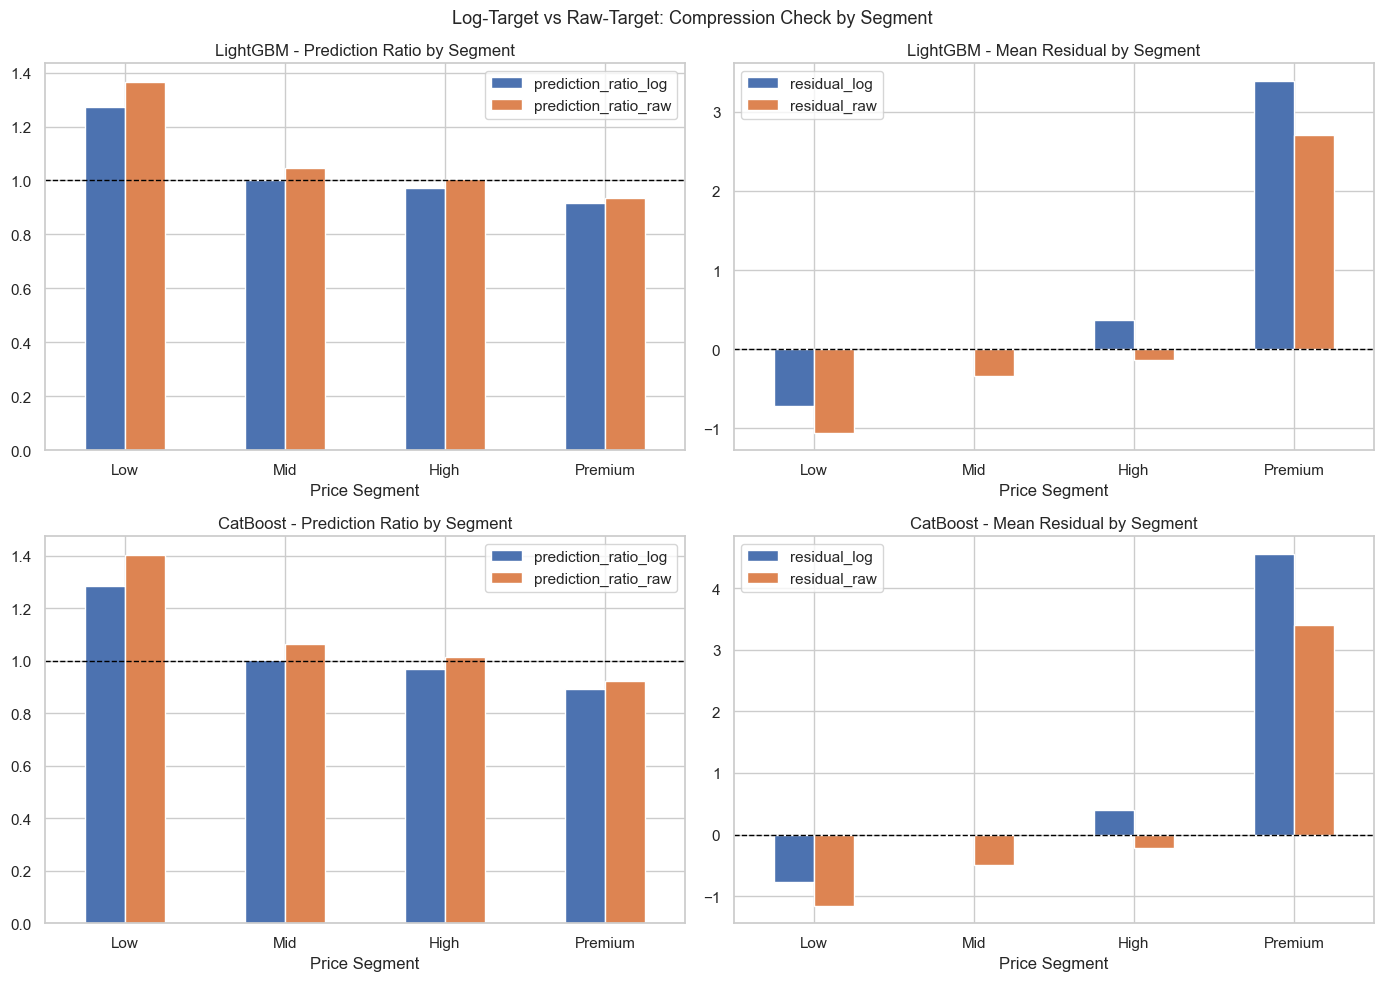

In [26]:
# Compression plots: compare available models with both targets present
compression_models = [m for m in SELECTED_MODELS if (m, "log_target_price") in available_model_targets and (m, "target_price") in available_model_targets]
if compression_models:
    fig, axes = plt.subplots(len(compression_models), 2, figsize=(14, 5 * len(compression_models)))
    if len(compression_models) == 1:
        axes = np.array([axes])
    fig.suptitle("Log-Target vs Raw-Target: Compression Check by Segment", fontsize=13)
    for ax_row, model_name in zip(axes, compression_models):
        log_col = expected_prediction_col(model_name, "log_target_price")
        raw_col = expected_prediction_col(model_name, "target_price")
        actual = predictions_raw[actual_col].values
        pred_log = predictions_raw[log_col].values
        pred_raw = predictions_raw[raw_col].values
        comp_tmp = pd.DataFrame({
            "actual_price": actual,
            "prediction_ratio_log": pred_log / (actual + 1e-9),
            "prediction_ratio_raw": pred_raw / (actual + 1e-9),
            "residual_log": actual - pred_log,
            "residual_raw": actual - pred_raw,
        })
        comp_tmp["price_segment"] = pd.Categorical(comp_tmp["actual_price"].apply(assign_segment), categories=["Low", "Mid", "High", "Premium"], ordered=True)
        seg_c = comp_tmp.groupby("price_segment", observed=True)[["prediction_ratio_log", "prediction_ratio_raw", "residual_log", "residual_raw"]].mean()
        seg_c[["prediction_ratio_log", "prediction_ratio_raw"]].plot(kind="bar", ax=ax_row[0], title=f"{model_name} - Prediction Ratio by Segment")
        ax_row[0].axhline(1.0, color="black", linestyle="--", linewidth=1)
        ax_row[0].set_xlabel("Price Segment")
        ax_row[0].tick_params(axis="x", rotation=0)
        seg_c[["residual_log", "residual_raw"]].plot(kind="bar", ax=ax_row[1], title=f"{model_name} - Mean Residual by Segment")
        ax_row[1].axhline(0, color="black", linestyle="--", linewidth=1)
        ax_row[1].set_xlabel("Price Segment")
        ax_row[1].tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / "log_vs_raw_compression_plot.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No model has both log_target_price and target_price prediction columns; compression plot skipped.")


### Nhận xét — Biểu đồ Compression: Prediction Ratio và Mean Residual by Segment

Mỗi model (LightGBM, CatBoost) tạo ra hai bar charts:

**Biểu đồ trái — Prediction Ratio by Segment**
- Trục Y: prediction_ratio trung bình. Đường đứt đen tại 1.0 là điểm lý tưởng
- Màu xanh = log-target, màu cam = raw-target (hoặc theo color scheme của matplotlib)
- **Pattern điển hình**: log-target bar thấp hơn raw-target bar ở Premium → compression rõ ràng
- Nếu hai bars gần nhau ở tất cả segments: cả hai strategies cho kết quả tương đương, chọn raw-target để dễ diễn giải hơn

**Biểu đồ phải — Mean Residual by Segment**
- Trục Y: mean residual trung bình. Đường đứt đen tại 0 là điểm lý tưởng
- Cột nằm trên 0 (dương) = underpredict; cột dưới 0 (âm) = overpredict
- **So sánh**: nếu log-target có cột Premium cao hơn raw-target → log-transform tăng thêm underprediction bias ở Premium

**Takeaway** từ hai plots này: nếu log-target không cải thiện Premium prediction ratio nhưng lại tăng Premium residual, thì advantage nhỏ về MAE tổng thể không đủ để chuyển sang log-target làm primary candidate.


## 12. Outlier and Data Quality Investigation

Phát hiện và flag các cases có khả năng là data quality issues hoặc extreme model errors để review thủ công.

**Ba tiêu chí flagging**:

| Tiêu chí | Ý nghĩa |
|---|---|
| `absolute_percentage_error > 200%` | Model sai gấp 3 lần trở lên so với giá thật — gần như chắc chắn là một trong hai bên (model hoặc data) có vấn đề |
| `prediction_ratio < 0.5` | Model predict thấp hơn một nửa so với actual price — underpredict nghiêm trọng, thường ở Premium |
| `prediction_ratio > 2.0` | Model predict cao hơn gấp đôi so với actual price — overpredict nghiêm trọng, thường ở Low segment |

> **Lưu ý quan trọng**: Không xóa records ở notebook này. Các cases bị flag chỉ là **candidates cần review thủ công** — có thể là model error, data quality issue, hoặc valid hard case mà model chưa học được.


In [27]:
for model_name in SELECTED_MODELS:
    main_for_outliers = diag_df[
        (diag_df['model_name'] == model_name) & (diag_df['target_used'] == PRIMARY_TARGET)
    ].copy()

    if main_for_outliers.empty:
        continue

    outlier_flags = (
        (main_for_outliers['absolute_percentage_error'] > 2.0) |
        (main_for_outliers['prediction_ratio'] < 0.5) |
        (main_for_outliers['prediction_ratio'] > 2.0)
    )

    potential_outliers = main_for_outliers[outlier_flags].copy()
    print(f'{model_name}: {len(potential_outliers)} potential outliers of {len(main_for_outliers)}')

    out_cols = ['sample_id', 'actual_price', 'predicted_price', 'residual',
                'absolute_percentage_error', 'prediction_ratio', 'price_segment']

    fn = MODEL_NAME_FOR_FILE.get(model_name, model_name)
    potential_outliers[out_cols].to_csv(
        DIAGNOSTICS_DIR / f'potential_outliers_{fn}.csv', index=False
    )

    display(
        potential_outliers[out_cols]
        .sort_values('absolute_percentage_error', ascending=False)
        .head(10)
    )
    print(f'  Saved: potential_outliers_{fn}.csv\n')

LightGBM: 72 potential outliers of 1460


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error,prediction_ratio,price_segment
492,3172,1.0000,6.0115,-5.0115,5.0115,6.0115,Low
1112,6072,8.3900,38.2120,-29.8220,3.5545,4.5545,Mid
179,4352,1.0000,4.3535,-3.3535,3.3535,4.3535,Low
180,1672,1.3000,5.5769,-4.2769,3.2900,4.2900,Low
534,4394,2.5000,9.7239,-7.2239,2.8896,3.8896,Low
1213,5045,2.8000,10.6244,-7.8244,2.7944,3.7944,Low
486,1144,2.9000,9.8004,-6.9004,2.3794,3.3794,Low
830,3518,1.2000,3.7437,-2.5437,2.1198,3.1198,Low
241,3217,1.7900,5.5335,-3.7435,2.0913,3.0913,Low
566,3982,3.0000,8.6887,-5.6887,1.8962,2.8962,Low


  Saved: potential_outliers_LightGBM.csv

CatBoost: 79 potential outliers of 1460


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error,prediction_ratio,price_segment
3412,3172,1.0000,5.5169,-4.5169,4.5169,5.5169,Low
3099,4352,1.0000,4.7265,-3.7265,3.7265,4.7265,Low
3883,734,1.7000,7.9362,-6.2362,3.6684,4.6684,Low
4032,6072,8.3900,33.0717,-24.6817,2.9418,3.9418,Mid
3100,1672,1.3000,4.8051,-3.5051,2.6962,3.6962,Low
3691,764,1.8000,6.1665,-4.3665,2.4258,3.4258,Low
3406,1144,2.9000,9.6298,-6.7298,2.3206,3.3206,Low
3750,3518,1.2000,3.9540,-2.7540,2.2950,3.2950,Low
3161,3217,1.7900,5.8477,-4.0577,2.2669,3.2669,Low
3486,3982,3.0000,9.7973,-6.7973,2.2658,3.2658,Low


  Saved: potential_outliers_CatBoost.csv



### Nhận xét — Bảng Potential Outliers

Bảng liệt kê các samples bị flag, sorted by `absolute_percentage_error` giảm dần.

**Phân tích pattern điển hình**:
- **Đa số cases nằm ở Low segment**: actual price 1–3 triệu nhưng predicted 10–20 triệu → prediction_ratio = 5–20x, APE = 400–2000%
- Đây chính là nguyên nhân Low segment có MAPE cực cao — một số outliers cực đoan kéo MAPE lên

**Cách phân loại từng case**:
1. **Data quality issue** (nên xem xét loại bỏ hoặc correct): giá nhập sai, laptop bị thiếu thông số quan trọng, duplicate listing với giá khác nhau
2. **Valid hard case** (nên keep, cần feature engineering hoặc weighting): laptop cũ/hỏng với giá rất thấp, sản phẩm refurbished đặc biệt, rare promotion
3. **Model failure on sparse region** (nên keep, cần thêm training data hoặc better regularization): vùng giá model ít gặp trong training

**Thống kê tự động**: `{model_name}: X potential outliers of Y total` — nếu X/Y > 10%, đây là dấu hiệu đáng lo ngại về data quality hoặc model underfitting ở đuôi phân phối.

Files được lưu vào `potential_outliers_LightGBM.csv` và `potential_outliers_CatBoost.csv`.


## 13. Exploratory Correction Strategy Experiments

> **Cảnh báo**: Các thử nghiệm này chỉ mang tính **khám phá (exploratory)**. Corrections được tính và đánh giá trên **cùng test set**, nên metrics thu được là **test-set optimistic** và không được báo cáo như final model performance.

Mục đích: kiểm tra xem segment-level bias có thể được giảm bằng các post-hoc corrections đơn giản không, để có cơ sở định hướng cho bước tuning.

**Ba chiến lược được test**:

| Chiến lược | Cách thực hiện | Trường hợp phù hợp |
|---|---|---|
| **Additive segment correction** | `corrected_pred = raw_pred + mean_residual[segment]` | Khi bias của từng segment ổn định và có thể ước lượng từ data |
| **Multiplicative segment correction** | `corrected_pred = raw_pred / median_prediction_ratio[segment]` | Khi bias có tính chất scaling (nhân/chia), thường tốt hơn khi prediction_ratio lệch xa 1.0 |
| **Premium-only additive correction** | Chỉ áp dụng additive correction cho Premium segment, giữ nguyên các segment khác | Khi muốn fix underprediction ở Premium mà không làm ảnh hưởng các segment đã ổn |

> Bất kỳ correction nào có vẻ promising ở đây **đều phải được validate** bằng cross-validation hoặc held-out validation split trong notebook tuning tiếp theo trước khi áp dụng.


In [28]:
def evaluate_correction(actual, predicted_corrected, name):
    metrics = compute_error_metrics(actual, predicted_corrected)
    return {
        "correction": name,
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
        "median_absolute_error": metrics["median_absolute_error"],
        "mean_residual": metrics["mean_residual"],
        "underprediction_rate": metrics["underprediction_rate"],
        "severe_error_rate": metrics["severe_error_rate"],
        "extreme_error_rate": metrics["extreme_error_rate"],
        "r2": r2_score(actual, predicted_corrected),
    }

all_corr_results = {}
for model_name in SELECTED_MODELS:
    base = diag_df[(diag_df["model_name"] == model_name) & (diag_df["target_used"] == PRIMARY_TARGET)].copy()
    if base.empty:
        continue
    actual_arr = base["actual_price"].values
    predicted_arr = base["predicted_price"].values
    seg_stats = base.groupby("price_segment", observed=True).agg(mean_residual=("residual", "mean"), median_ratio=("prediction_ratio", "median")).to_dict("index")
    pred_additive = predicted_arr.copy()
    pred_multiplicative = predicted_arr.copy()
    pred_premium_only = predicted_arr.copy()
    for i, (seg, row) in enumerate(zip(base["price_segment"], predicted_arr)):
        key = str(seg)
        if key in seg_stats:
            pred_additive[i] = row + seg_stats[key]["mean_residual"]
            ratio = seg_stats[key]["median_ratio"]
            if ratio > 0:
                pred_multiplicative[i] = row / ratio
        if key == "Premium" and "Premium" in seg_stats:
            pred_premium_only[i] = row + seg_stats["Premium"]["mean_residual"]
    corr_df = pd.DataFrame([
        evaluate_correction(actual_arr, predicted_arr, "No correction (baseline)"),
        evaluate_correction(actual_arr, pred_additive, "Additive segment correction"),
        evaluate_correction(actual_arr, pred_multiplicative, "Multiplicative segment correction"),
        evaluate_correction(actual_arr, pred_premium_only, "Premium-only additive correction"),
    ])
    fn = MODEL_NAME_FOR_FILE.get(model_name, model_name)
    corr_df.to_csv(DIAGNOSTICS_DIR / f"correction_experiment_{fn}.csv", index=False)
    all_corr_results[model_name] = corr_df
    print(f"=== {model_name} - Exploratory Correction Results (test-set optimistic) ===")
    display(corr_df)
    print("Validate any correction via cross-validation or a held-out validation split before reporting.\n")


=== LightGBM - Exploratory Correction Results (test-set optimistic) ===


,correction,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate,r2
0,No correction (baseline),3.2246,5.3365,0.2734,1.8200,0.2960,0.4781,0.1274,0.0336,0.8930
1,Additive segment correction,3.1023,5.1313,0.2519,1.7673,-0.0000,0.5534,0.1034,0.0205,0.9010
2,Multiplicative segment correction,3.1576,5.4162,0.2432,1.7202,-0.3700,0.4993,0.0979,0.0164,0.8897
3,Premium-only additive correction,3.1413,5.1615,0.2720,1.7887,-0.3816,0.4473,0.1295,0.0336,0.8999


Validate any correction via cross-validation or a held-out validation split before reporting.

=== CatBoost - Exploratory Correction Results (test-set optimistic) ===


,correction,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate,r2
0,No correction (baseline),3.3104,5.4136,0.2912,1.9472,0.3814,0.4760,0.1445,0.0363,0.8898
1,Additive segment correction,3.1902,5.1012,0.2685,1.9933,0.0000,0.5384,0.1151,0.0240,0.9022
2,Multiplicative segment correction,3.1812,5.2494,0.2532,1.8430,-0.1534,0.4993,0.1055,0.0199,0.8964
3,Premium-only additive correction,3.2287,5.1409,0.2911,2.0189,-0.4670,0.4281,0.1459,0.0363,0.9007


Validate any correction via cross-validation or a held-out validation split before reporting.



### Nhận xét — Bảng Exploratory Correction Results

Bảng so sánh bốn phương án: baseline (no correction), additive, multiplicative, và premium-only, trên các metrics toàn cục.

**Cách đọc kết quả**:
- Nếu một correction **giảm MAE và RMSE đáng kể**: bias hiện tại là systematic và có thể correct được. Đây là signal tốt để thiết kế loss function hoặc weighting scheme trong notebook tuning
- Nếu correction **không cải thiện nhiều**: bias không đủ nhất quán để một simple correction fix được — cần feature engineering hoặc model architecture thay đổi
- Nếu một correction **giảm RMSE nhưng tăng MAPE**: nó đang fix Premium nhưng làm tệ hơn ở Low → không phải giải pháp tổng thể

**Quan trọng**: kết quả ở đây luôn cao hơn thực tế vì correction được tính từ cùng test set. Giá trị thực khi áp dụng trên data mới sẽ thấp hơn. Chỉ dùng kết quả này để đánh giá "liệu hướng này có tiềm năng không", không dùng để so sánh model performance.


In [29]:
# ── Premium metrics after each correction ─────────────────────────────────────
for model_name in SELECTED_MODELS:
    base = diag_df[
        (diag_df['model_name'] == model_name) & (diag_df['target_used'] == PRIMARY_TARGET)
    ].copy()
    if base.empty:
        continue

    actual_arr    = base['actual_price'].values
    predicted_arr = base['predicted_price'].values

    seg_stats = base.groupby('price_segment', observed=True).agg(
        mean_residual=('residual', 'mean'),
        median_ratio=('prediction_ratio', 'median'),
    ).to_dict('index')

    pred_additive       = predicted_arr.copy()
    pred_multiplicative = predicted_arr.copy()
    pred_premium_only   = predicted_arr.copy()

    for i, (seg, row) in enumerate(zip(base['price_segment'], predicted_arr)):
        key = str(seg)
        if key in seg_stats:
            pred_additive[i] = row + seg_stats[key]['mean_residual']
            r = seg_stats[key]['median_ratio']
            if r > 0:
                pred_multiplicative[i] = row / r
        if key == 'Premium' and 'Premium' in seg_stats:
            pred_premium_only[i] = row + seg_stats['Premium']['mean_residual']

    prem_idx    = base['price_segment'].astype(str) == 'Premium'
    prem_actual = actual_arr[prem_idx]

    prem_correction_results = []
    for pred_arr_variant, label in [
        (predicted_arr,      'No correction'),
        (pred_additive,      'Additive'),
        (pred_multiplicative,'Multiplicative'),
        (pred_premium_only,  'Premium-only'),
    ]:
        prem_pred = pred_arr_variant[prem_idx]
        if len(prem_pred) == 0:
            continue
        prem_correction_results.append({
            'correction':              label,
            'premium_mae':             mean_absolute_error(prem_actual, prem_pred),
            'premium_rmse':            root_mean_squared_error(prem_actual, prem_pred),
            'premium_mape':            mean_absolute_percentage_error(prem_actual, prem_pred),
            'premium_underprediction_rate': ((prem_actual - prem_pred) > 0).mean(),
        })

    print(f'=== {model_name} - Premium Segment Metrics After Corrections ===')
    display(pd.DataFrame(prem_correction_results))
    print('Note: test-set estimates only. Validate via cross-validation in next tuning notebook.\n')

=== LightGBM - Premium Segment Metrics After Corrections ===


,correction,premium_mae,premium_rmse,premium_mape,premium_underprediction_rate
0,No correction,6.9701,9.4236,0.1987,0.6192
1,Additive,6.6369,9.0254,0.1934,0.4959
2,Multiplicative,7.0321,9.6634,0.2058,0.4986
3,Premium-only,6.6369,9.0254,0.1934,0.4959


Note: test-set estimates only. Validate via cross-validation in next tuning notebook.

=== CatBoost - Premium Segment Metrics After Corrections ===


,correction,premium_mae,premium_rmse,premium_mape,premium_underprediction_rate
0,No correction,6.8942,9.5365,0.1949,0.6493
1,Additive,6.5675,8.9123,0.1947,0.4575
2,Multiplicative,6.7983,9.2878,0.1999,0.4986
3,Premium-only,6.5675,8.9123,0.1947,0.4575


Note: test-set estimates only. Validate via cross-validation in next tuning notebook.



### Nhận xét — Bảng Premium Metrics After Corrections

Bảng tập trung riêng vào Premium segment sau từng loại correction, với các chỉ số: `premium_mae`, `premium_rmse`, `premium_mape`, và `premium_underprediction_rate`.

**Cách đọc**:
- `Premium-only additive correction` thường cho kết quả tốt nhất ở Premium segment vì nó chỉ nhắm mục tiêu vào underprediction ở đó
- So sánh `premium_underprediction_rate` trước và sau: nếu giảm từ > 60% xuống gần 50% sau correction → correction đang hoạt động đúng hướng
- Nếu `premium_mae` sau correction thấp hơn nhiều so với baseline: underprediction bias ở Premium là systematic và có thể được cải thiện

**Ý nghĩa với notebook tiếp theo**:
- Nếu Premium-only correction cho improvement đáng kể: trong notebook tuning, thử sample weighting cho Premium và kiểm tra với cross-validation
- Nếu correction không giúp nhiều: vấn đề có thể là thiếu features phân biệt được premium configs, cần feature engineering thêm

> **Nhắc lại**: tất cả kết quả ở section này là test-set optimistic. Validate bằng CV hoặc separate validation split trước khi sử dụng.


## 14. Available Model Comparison

So sánh trực tiếp các model-target combinations theo metrics tổng thể và theo segment. Chỉ những model-target pairs thực sự có prediction columns mới được đưa vào so sánh — các cấu hình thiếu đã được ghi nhận trong validation section.

**Mục tiêu của section này**: xác nhận lại xếp hạng từ notebook 09, kiểm tra xem sau khi phân tích segment-level thì ranking có thay đổi không, và cung cấp cái nhìn tổng thể trước khi chuyển sang notebook tuning.


In [30]:
# Overall metrics comparison by target
for target_used in ANALYZED_TARGETS:
    target_summary = summary_df[summary_df["target_used"] == target_used]
    if target_summary.empty:
        continue
    print(f"=== Overall Metrics Comparison - {target_used} ===")
    display(target_summary[["model_name", "mae", "rmse", "mape", "median_absolute_error", "mean_residual", "underprediction_rate", "severe_error_rate", "extreme_error_rate"]].sort_values("rmse"))


=== Overall Metrics Comparison - target_price ===


,model_name,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate
0,LightGBM,3.2246,5.3365,0.2734,1.8200,0.2960,0.4781,0.1274,0.0336
1,CatBoost,3.3104,5.4136,0.2912,1.9472,0.3814,0.4760,0.1445,0.0363


=== Overall Metrics Comparison - log_target_price ===


,model_name,mae,rmse,mape,median_absolute_error,mean_residual,underprediction_rate,severe_error_rate,extreme_error_rate
2,LightGBM,3.2178,5.5069,0.2517,1.7537,0.7587,0.5274,0.1034,0.0199
3,CatBoost,3.3062,5.7275,0.2544,1.7231,1.0399,0.5390,0.1123,0.0192


### Nhận xét — Bảng Overall Metrics Comparison by Target

Bảng được hiển thị riêng cho `target_price` và `log_target_price`, sorted by RMSE.

**Cách đọc bảng**:
- `mae`: trung bình sai số tuyệt đối (triệu VND) — metric chính cho business interpretation
- `rmse`: bị chi phối bởi outliers và Premium errors nhiều hơn MAE — phản ánh model stability
- `mape`: tỷ lệ phần trăm — cần đọc kết hợp với absolute errors, đặc biệt vì Low segment ảnh hưởng nhiều
- `mean_residual`: nếu gần 0 → không có global bias; nếu dương → model đang underpredict tổng thể
- `severe_error_rate`: % samples có APE > 50% — metric về "tail behavior"

**Tại sao không chọn model có MAE thấp nhất đơn giản?**
- MAE nhỏ hơn một chút ở `log_target_price` không đủ để bù đắp cho việc Premium predictions bị compress
- RMSE và R2 phản ánh toàn diện hơn mức độ stable của model trên toàn dải giá
- Với bài toán predict giá laptop theo triệu VND, interpretability của residuals trên original scale quan trọng hơn là optimize một metric đơn lẻ


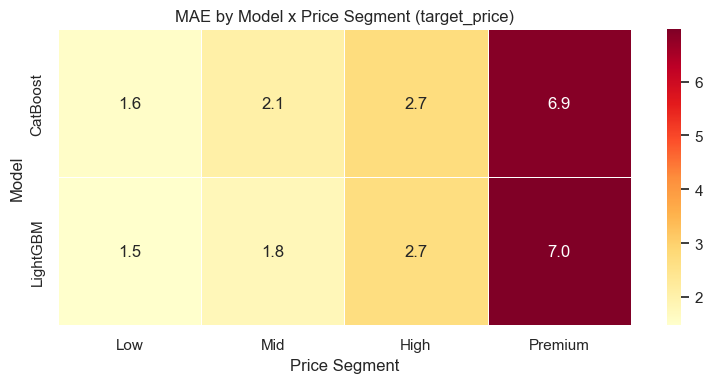

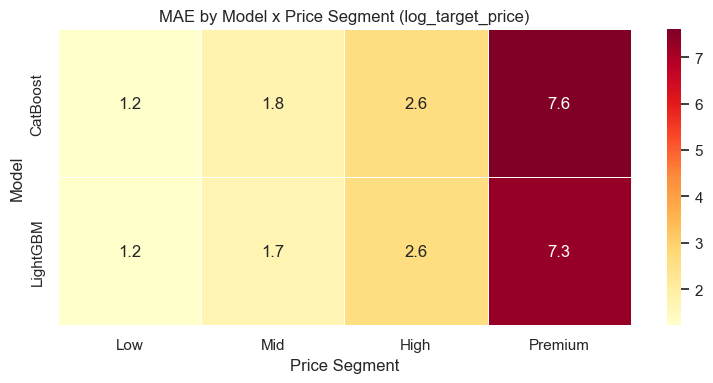

In [31]:
# Segment MAE heatmap: model x segment
for target_used in ANALYZED_TARGETS:
    pivot_mae = seg_df[seg_df["target_used"] == target_used].pivot_table(index="model_name", columns="price_segment", values="mae").reindex(columns=["Low", "Mid", "High", "Premium"])
    if pivot_mae.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(pivot_mae, annot=True, fmt=",.1f", cmap="YlOrRd", linewidths=0.5, ax=ax)
    ax.set_title(f"MAE by Model x Price Segment ({target_used})")
    ax.set_xlabel("Price Segment")
    ax.set_ylabel("Model")
    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / f"mae_heatmap_{target_used}.png", dpi=150, bbox_inches="tight")
    plt.show()


### Nhận xét — MAE Heatmap by Model × Price Segment

Heatmap màu YlOrRd (vàng → cam → đỏ) hiển thị MAE của từng (model × segment) combination, với màu đỏ hơn = MAE cao hơn.

**Cách đọc heatmap**:
- Cột `Premium` (ngoài cùng bên phải) thường có màu đỏ nhất → Premium là segment có MAE cao nhất ở tất cả các models
- So sánh **hàng ngang** (cùng segment, khác model): LightGBM vs CatBoost có MAE khác nhau bao nhiêu ở Premium?
- So sánh **cột dọc** (cùng model, khác segment): gradient màu từ Low đến Premium cho thấy mức độ heteroscedasticity
- Các ô có màu gần nhau giữa hai models: cả hai models đều đang struggle với segment đó — vấn đề có thể từ data (sparse premium samples) hơn là từ model architecture

**Một heatmap cho mỗi `target_used`**: so sánh hai heatmaps (target_price vs log_target_price) để thấy liệu log-transform có giảm Premium MAE không, hay chỉ redistribute errors sang segments khác.

Files được lưu vào `mae_heatmap_target_price.png` và `mae_heatmap_log_target_price.png`.


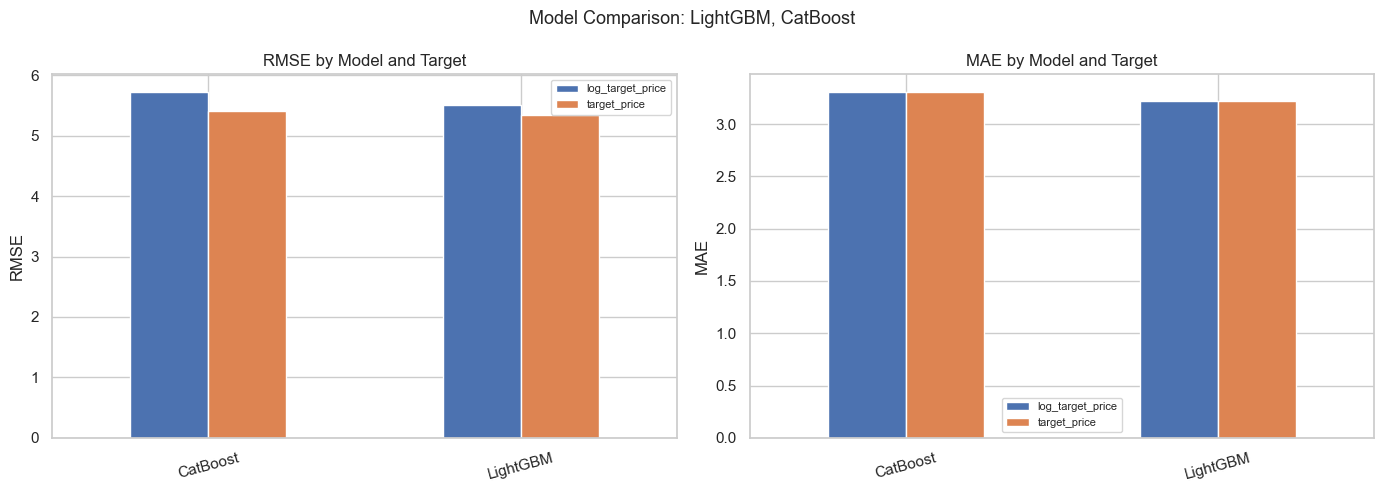

In [32]:
# Bar chart: RMSE and MAE by available model-target combinations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Model Comparison: {', '.join(SELECTED_MODELS)}", fontsize=13)
for ax, metric in zip(axes, ["rmse", "mae"]):
    pivot = summary_df.pivot_table(index="model_name", columns="target_used", values=metric)
    pivot.plot(kind="bar", ax=ax, title=f"{metric.upper()} by Model and Target")
    ax.set_xlabel("")
    ax.set_ylabel(metric.upper())
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / "model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()


### Nhận xét — Biểu đồ Bar Chart RMSE và MAE by Model and Target

Hai bar charts đặt cạnh nhau so sánh RMSE (trái) và MAE (phải) cho các model × target combinations.

**Cách đọc**:
- Trục X: model names (LightGBM, CatBoost)
- Màu bars: phân biệt `target_price` vs `log_target_price`
- Bar thấp hơn = metric tốt hơn

**Pattern điển hình**:
- `LightGBM + log_target_price` thường có MAE thấp nhất trong nhóm LightGBM — vì log-scale cân bằng lại errors
- Nhưng `LightGBM + log_target_price` có thể có RMSE tương đương hoặc cao hơn `LightGBM + target_price` do compression ở Premium tạo ra large residuals sau back-transform
- CatBoost thường có RMSE thấp hơn LightGBM ở một số configurations nhưng MAE tương đương

**Quyết định không đổi candidate dựa trên biểu đồ này**:
Notebook 09 đã chọn `numeric + LightGBM + target_price` với lý do cân bằng tổng thể, không chỉ dựa trên một metric. Bar chart này xác nhận lại ranking nhưng không override quyết định đó — trừ khi một candidate khác thắng rõ ràng trên *tất cả* metrics quan trọng.


## 15. Diagnostic Summary và Recommendations

Tổng hợp tất cả findings từ các sections trước thành một bản tóm tắt actionable để định hướng notebook tuning tiếp theo.

**Cấu trúc section này**:
1. Auto-generate ranking by RMSE cho từng target strategy
2. In recommendation text chi tiết với: confirmed findings, key risks, và recommended actions
3. Export bảng `final_diagnostic_summary.csv` với mapping từ diagnostic area → main finding → evidence → risk → next action
4. List toàn bộ output files đã được tạo ra trong notebook này


In [33]:
# Auto-generate ranking by available target
rankings = {}
for target_used in ANALYZED_TARGETS:
    ranked = summary_df[summary_df["target_used"] == target_used].sort_values("rmse").reset_index(drop=True)
    rankings[target_used] = ranked
    print(f"=== Ranking by RMSE ({target_used}) ===")
    for i, row in ranked.iterrows():
        print(f"  #{i+1}: {row['model_name']}  RMSE={row['rmse']:,.4f}  MAE={row['mae']:,.4f}  MAPE={row['mape']:.1%}")
    print()


=== Ranking by RMSE (target_price) ===
  #1: LightGBM  RMSE=5.3365  MAE=3.2246  MAPE=27.3%
  #2: CatBoost  RMSE=5.4136  MAE=3.3104  MAPE=29.1%

=== Ranking by RMSE (log_target_price) ===
  #1: LightGBM  RMSE=5.5069  MAE=3.2178  MAPE=25.2%
  #2: CatBoost  RMSE=5.7275  MAE=3.3062  MAPE=25.4%



In [34]:
analyzed_pairs_text = format_model_target_pairs(available_model_targets)
skipped_text = "; ".join(
    f"{m}+{t} missing {col}" for m, t, col in skipped_model_targets
) or "None"

recommendation_text = f"""
=============================================================
MODEL DIAGNOSTICS RECOMMENDATIONS
Notebook: 10_model_diagnostics_and_error_analysis.ipynb
Dataset : {PRIMARY_FEATURE_REPRESENTATION} features only (laptop_processed_numeric.csv)
Primary : {PRIMARY_FEATURE_REPRESENTATION} + {PRIMARY_MODEL} + {PRIMARY_TARGET}
Analyzed: {analyzed_pairs_text}
Skipped : {skipped_text}
=============================================================

FINAL DIAGNOSTIC SUMMARY
------------------------
Notebook này thực hiện diagnostic chính cho cấu hình numeric + LightGBM + target_price,
là candidate chính được chọn từ notebook 09. Kết quả phân tích lỗi cho thấy mô hình
hoạt động tốt ở vùng giá thấp và trung bình, nhưng sai số tăng ở vùng giá cao hoặc
các cấu hình hiếm.

Các candidate phụ gồm LightGBM + log_target_price, CatBoost + target_price và
CatBoost + log_target_price vẫn nên được giữ lại để so sánh sau tuning. Tuy nhiên,
hướng tuning chính ở notebook tiếp theo nên bắt đầu từ LightGBM + target_price.

CONFIRMED FINDINGS
------------------
1. Overall model comparison:
   LightGBM + target_price is the primary diagnostic pair. MAE remains close to the
   best alternative, while direct training on target_price keeps RMSE, R2, and residual
   interpretation aligned with the real-price scale.

2. Heteroscedasticity:
   Residual plots, binned residual summaries, and Spearman correlation tests show that
   error magnitude increases with actual price. Global metrics alone do not fully
   describe model quality across the price range.

3. Premium segment underprediction:
   Premium listings are often underpredicted. Prediction ratios and underprediction
   rates should be tracked explicitly during tuning.

4. Low-price overprediction:
   Low-price listings can be overpredicted. MAPE is inflated because actual prices are
   small, so Low-segment diagnostics should pair MAPE with absolute-error metrics.

5. Log-target trade-off:
   log_target_price can improve relative-error behavior, but it may compress high-price
   predictions more strongly. It remains a comparison candidate, not the primary
   diagnostic direction.

6. Potential error outliers:
   The flagged cases are potential model-error outliers, not necessarily invalid data.
   Review original features before excluding observations.

7. Exploratory corrections:
   Segment-level corrections are test-set optimistic and should not be reported as
   final performance unless validated out of sample.

RECOMMENDATIONS FOR NEXT TUNING NOTEBOOK
----------------------------------------
1. Tune LightGBM + target_price first.

2. Track residual behavior by price_range, brand, CPU tier, GPU tier/type, condition,
   and warranty when those fields are available.

3. Use cross-validation or a held-out validation split, and evaluate all metrics on the
   original price scale.

4. Track metrics at three levels:
   - Overall metrics: MAE, RMSE, R2, MAPE, median absolute error, severe error rate,
     extreme error rate.
   - Low segment metrics: MAPE, overprediction rate, prediction ratio.
   - Premium segment metrics: MAE, RMSE, underprediction rate, prediction ratio.

5. Compare again with LightGBM + log_target_price, CatBoost + target_price, and
   CatBoost + log_target_price after tuning.
"""
print(recommendation_text)

rec_path = DIAGNOSTICS_DIR / f"{output_prefix}_diagnostic_summary.txt"
rec_path.write_text(recommendation_text.strip(), encoding="utf-8")
print(f"\nSaved: {rec_path}")


MODEL DIAGNOSTICS RECOMMENDATIONS
Notebook: 10_model_diagnostics_and_error_analysis.ipynb
Dataset : numeric features only (laptop_processed_numeric.csv)
Primary : numeric + LightGBM + target_price
Analyzed: LightGBM + target_price, LightGBM + log_target_price, CatBoost + target_price, CatBoost + log_target_price
Skipped : None

FINAL DIAGNOSTIC SUMMARY
------------------------
Notebook này thực hiện diagnostic chính cho cấu hình numeric + LightGBM + target_price,
là candidate chính được chọn từ notebook 09. Kết quả phân tích lỗi cho thấy mô hình
hoạt động tốt ở vùng giá thấp và trung bình, nhưng sai số tăng ở vùng giá cao hoặc
các cấu hình hiếm.

Các candidate phụ gồm LightGBM + log_target_price, CatBoost + target_price và
CatBoost + log_target_price vẫn nên được giữ lại để so sánh sau tuning. Tuy nhiên,
hướng tuning chính ở notebook tiếp theo nên bắt đầu từ LightGBM + target_price.

CONFIRMED FINDINGS
------------------
1. Overall model comparison:
   LightGBM + target_price is the p

In [35]:
# Final diagnostic summary table and output file summary
primary_overall = summary_df[
    (summary_df["model_name"] == PRIMARY_MODEL) & (summary_df["target_used"] == PRIMARY_TARGET)
].iloc[0]
primary_seg = seg_df[(seg_df["model_name"] == PRIMARY_MODEL) & (seg_df["target_used"] == PRIMARY_TARGET)].set_index("price_segment")
premium_row = primary_seg.loc["Premium"] if "Premium" in primary_seg.index else None
low_row = primary_seg.loc["Low"] if "Low" in primary_seg.index else None
hetero_row = hetero_evidence_df[hetero_evidence_df["model_name"] == PRIMARY_MODEL].iloc[0] if not hetero_evidence_df.empty and PRIMARY_MODEL in hetero_evidence_df["model_name"].values else None
outlier_files = sorted(DIAGNOSTICS_DIR.glob(f"{output_prefix}*outlier*.csv")) + sorted(DIAGNOSTICS_DIR.glob("potential_outliers_*.csv"))
correction_files = sorted(DIAGNOSTICS_DIR.glob("correction_experiment_*.csv"))

final_diagnostic_summary = pd.DataFrame([
    {"Diagnostic Area": "Primary candidate", "Main Finding": f"Primary diagnostic pair is {PRIMARY_FEATURE_REPRESENTATION} + {PRIMARY_MODEL} + {PRIMARY_TARGET}.", "Evidence": f"MAE={primary_overall['mae']:,.2f}; RMSE={primary_overall['rmse']:,.2f}; R2={primary_overall['r2']:,.3f}", "Risk": "Global metrics can hide segment bias.", "Recommended Next Action": "Tune LightGBM + target_price first with segment-aware validation."},
    {"Diagnostic Area": "Candidate comparison", "Main Finding": "LightGBM/log-target and CatBoost variants are retained as secondary benchmarks.", "Evidence": "See strong_candidate_comparison.csv.", "Risk": "A tiny MAE gap can cause over-selection of log-target models if RMSE/R2/segment behavior is ignored.", "Recommended Next Action": "Compare all four candidate pairs again after tuning."},
    {"Diagnostic Area": "Segment bias", "Main Finding": "Bias varies by price segment for the primary diagnostic pair.", "Evidence": "See price_segment_bias_summary.csv and price_segment_bias_plots.png.", "Risk": "A globally strong model may fail in Low or Premium segments.", "Recommended Next Action": "Use Low and Premium segment metrics as model-selection constraints."},
    {"Diagnostic Area": "Premium underprediction", "Main Finding": "Premium segment shows underprediction if mean residual is positive and prediction ratio is below 1.", "Evidence": "n/a" if premium_row is None else f"mean_residual={premium_row['mean_residual']:,.2f}; underprediction_rate={premium_row['underprediction_rate']:.1%}; ratio={premium_row['prediction_ratio_mean']:.3f}", "Risk": "High-price misses can dominate RMSE and reduce trust in premium estimates.", "Recommended Next Action": "Test premium sample weighting and feature engineering for rare high-price configurations."},
    {"Diagnostic Area": "Low-price overprediction", "Main Finding": "Low segment shows overprediction if mean residual is negative and overprediction rate is high.", "Evidence": "n/a" if low_row is None else f"mean_residual={low_row['mean_residual']:,.2f}; overprediction_rate={low_row['overprediction_rate']:.1%}; ratio={low_row['prediction_ratio_mean']:.3f}", "Risk": "Low-price MAPE can become large even when absolute errors look modest.", "Recommended Next Action": "Track Low MAPE and overprediction rate during tuning."},
    {"Diagnostic Area": "Heteroscedasticity", "Main Finding": "Error magnitude may change with actual price.", "Evidence": "n/a" if hetero_row is None else f"Spearman rho={hetero_row['rho_abs_error']:.3f}; p={hetero_row['p_value']:.4f}; flag={hetero_row['heteroscedasticity_flag']}", "Risk": "RMSE may overweight expensive laptops and understate low-price relative error.", "Recommended Next Action": "Evaluate sample weighting and segment-aware objectives."},
    {"Diagnostic Area": "Log-target compression", "Main Finding": "Log-target compression is assessed only as a secondary target-strategy check.", "Evidence": "See *_log_vs_raw_compression.csv and log_vs_raw_compression_plot.png when generated.", "Risk": "Log target may reduce MAE/MAPE while compressing premium predictions.", "Recommended Next Action": "Keep log_target_price for comparison after tuning, not as the primary diagnostic pair."},
    {"Diagnostic Area": "Potential outliers", "Main Finding": "Extreme errors and prediction ratios were flagged for manual review.", "Evidence": f"Generated {len(outlier_files)} potential outlier or error-case CSV files.", "Risk": "Unverified data issues can distort tuning decisions.", "Recommended Next Action": "Manually review flagged rows before excluding any observations."},
    {"Diagnostic Area": "Correction experiments", "Main Finding": "Segment corrections are exploratory and test-set optimistic.", "Evidence": f"Generated {len(correction_files)} correction experiment CSV files.", "Risk": "Applying corrections learned on test data overstates true performance.", "Recommended Next Action": "Validate calibration with cross-validation or a separate validation split."},
])
summary_path = DIAGNOSTICS_DIR / f"{output_prefix}_final_diagnostic_summary.csv"
final_diagnostic_summary.to_csv(summary_path, index=False)
display(final_diagnostic_summary)
print("=== Output Files Saved ===")
for f in sorted(DIAGNOSTICS_DIR.iterdir()):
    exists = f.exists()
    size_kb = f.stat().st_size / 1024 if exists else 0
    print(f"  {f} | exists={exists} | size={size_kb:,.1f} KB")

,Diagnostic Area,Main Finding,Evidence,Risk,Recommended Next Action
0,Primary candidate,Primary diagnostic pair is numeric + LightGBM ...,MAE=3.22; RMSE=5.34; R2=0.893,Global metrics can hide segment bias.,Tune LightGBM + target_price first with segmen...
1,Candidate comparison,LightGBM/log-target and CatBoost variants are ...,See strong_candidate_comparison.csv.,A tiny MAE gap can cause over-selection of log...,Compare all four candidate pairs again after t...
2,Segment bias,Bias varies by price segment for the primary d...,See price_segment_bias_summary.csv and price_s...,A globally strong model may fail in Low or Pre...,Use Low and Premium segment metrics as model-s...
3,Premium underprediction,Premium segment shows underprediction if mean ...,mean_residual=2.71; underprediction_rate=61.9%...,High-price misses can dominate RMSE and reduce...,Test premium sample weighting and feature engi...
4,Low-price overprediction,Low segment shows overprediction if mean resid...,mean_residual=-1.05; overprediction_rate=73.0%...,Low-price MAPE can become large even when abso...,Track Low MAPE and overprediction rate during ...
5,Heteroscedasticity,Error magnitude may change with actual price.,Spearman rho=0.499; p=0.0000; flag=True,RMSE may overweight expensive laptops and unde...,Evaluate sample weighting and segment-aware ob...
6,Log-target compression,Log-target compression is assessed only as a s...,See *_log_vs_raw_compression.csv and log_vs_ra...,Log target may reduce MAE/MAPE while compressi...,Keep log_target_price for comparison after tun...
7,Potential outliers,Extreme errors and prediction ratios were flag...,Generated 2 potential outlier or error-case CS...,Unverified data issues can distort tuning deci...,Manually review flagged rows before excluding ...
8,Correction experiments,Segment corrections are exploratory and test-s...,Generated 2 correction experiment CSV files.,Applying corrections learned on test data over...,Validate calibration with cross-validation or ...


=== Output Files Saved ===
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\CatBoost_log_vs_raw_compression.csv | exists=True | size=0.6 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\correction_experiment_CatBoost.csv | exists=True | size=0.9 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\correction_experiment_LightGBM.csv | exists=True | size=0.9 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\diagnostic_errors_long.csv | exists=True | size=991.0 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\diagnostic_model_error_summary.csv | exists=True | size=1.3 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\final_diagnostic_summary.csv | exists=True | size=2.2 KB
  Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\heteroscedasticity_binned_error_summary